# alternatives-analysis

Boulder Valley's Resilient Schools proposal recommends closing four
elementary schools. It is presented as a single plan. This notebook asks
three questions the plan does not:

1. **Has this happened before?** Colorado has been closing schools for forty
   years. What predicts a closure, and what happened afterwards?
2. **How many schools does the demography actually support?** Fitted across
   every Colorado district rather than Boulder's own history, and carried to
   2060 with the uncertainty attached.
3. **What are the options?** Closing schools is one lever. There are others,
   and each is judged here on what it is actually trying to do.

**Financials are out of scope by instruction.** Nothing below costs or saves
money. The question is whether there are enough children.

Everything is read from `data/analysis/`, written by
`alternatives-retrieval.ipynb`. No network call is made and no key is read.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=FutureWarning)
HERE = Path.cwd()
ANALYSIS = HERE / "data" / "analysis"
OUTPUT = HERE / "output"
OUTPUT.mkdir(exist_ok=True)

BVSD_CODE = "0480"
SVVSD_CODE = "0470"           # St Vrain Valley, the neighbouring district
BOULDER_FIPS = "013"

INK = "#22303f"
ACCENT = "#c1440e"
MUTED = "#8a9aa8"
GRID = "#dfe5ea"
PALETTE = ["#22303f", "#c1440e", "#3d7068", "#b08968", "#6b7a8f", "#8c5e58"]
mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.labelcolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9, "axes.spines.top": False,
    "axes.spines.right": False, "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "text.color": INK,
    "grid.color": GRID, "grid.linewidth": 0.7, "legend.frameon": False,
    "legend.fontsize": 8.5, "font.size": 9.5,
})

def finish(ax, title, subtitle=None, source=None):
    """House style: title above, source below, horizontal grid only."""
    ax.set_title(title, pad=18 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9,
                color=MUTED, va="bottom")
    ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
    if source:
        ax.figure.text(0.01, -0.02, source, fontsize=7.5, color=MUTED, ha="left")
    return ax

codes = {"district_code": str, "school_code": str, "ncessch": str, "countyfips": str}
panel = pd.read_csv(ANALYSIS / "district-panel.csv", dtype=codes)
school_panel = pd.read_csv(ANALYSIS / "school-panel.csv", dtype=codes)
registry = pd.read_csv(ANALYSIS / "school-registry.csv", dtype=codes)
bvsd_schools = pd.read_csv(ANALYSIS / "bvsd-schools.csv", dtype=codes)
proposal_actions = pd.read_csv(ANALYSIS / "proposal-actions.csv", dtype=codes)
proposal_figures = pd.read_csv(ANALYSIS / "proposal-figures.csv")
proposal_capacity = pd.read_csv(ANALYSIS / "proposal-capacity.csv", dtype=codes)
says = proposal_figures.set_index("name")["value"]
print(f"district panel   {len(panel):,} rows   {panel['year'].min()}-{panel['year'].max()}"
      f"   {panel['district_code'].nunique()} districts")
print(f"school panel     {len(school_panel):,} rows")
print(f"BVSD schools     {len(bvsd_schools)} in {int(bvsd_schools['year'].iloc[0])}")

district panel   6,190 rows   1990-2024   179 districts
school panel     66,929 rows
BVSD schools     56 in 2024


## 1. Colorado has been closing schools the whole time

The first thing the archive says is that closure is not an event. It is a
rate. Between 1986 and 2024 Colorado schools disappeared from the panel
every single year, in good demographic times and bad — while the number of
schools rose by half.

The labels come from the archive, which assigns them **from the data alone
and never hand-verifies them** (`decision-log.md`, D6). A closure, a merger,
a rename and a code change can look alike. The confidence column travels
with every figure below, and Boulder's own closures are checked one by one
further down, because that is where the argument rests on buildings.

In [2]:
# When is a school "closed"? The archive records the years it is observed and
# a label for its disappearance. Two choices turn that into an event.
#
# **Which disappearances count.** Only those the registry labels `closed` or
# `merged`. A rename or a code change is the same building under another
# name, and the registry's confidence column says how sure it is.
#
# **Which year to measure.** Not the last one. A closing school's final
# observed year is not a normal year of operation - only 39 of the 656
# closing schools have an enrollment recorded in it at all, and the median of
# those is 75 pupils against 391 for every school that year. Measuring a
# school at the moment of its collapse and then finding that small schools
# close is circular.
#
# So the event is **gone within two years**: the school is observed in year t,
# absent from t+2 onward, and labelled closed or merged. Year t is still a
# normal year - 564 of the 656 have an enrollment in it.
panel_end = int(school_panel["year"].max())
sp = school_panel.dropna(subset=["ncessch"]).sort_values(["ncessch", "year"]).copy()
shut = set(sp.loc[sp["closure_label"].isin(["closed", "merged"]), "ncessch"])
last_seen = sp.groupby("ncessch")["year"].max()
# One event per school, in its last normal year. The final observed year is
# dropped from the risk set altogether: a school in the middle of closing is
# neither a school that survived nor a fair measurement of one.
sp["is_final_year"] = sp["year"] == sp["ncessch"].map(last_seen)
sp = sp[~sp["is_final_year"]].copy()
closing_year = {school: year - 1 for school, year in last_seen.items()
                if school in shut and year < panel_end}
sp["gone_in_2"] = [int(closing_year.get(row.ncessch) == row.year)
                   for row in sp.itertuples()]
events = sp[sp["gone_in_2"] == 1]
print(f"{len(sp):,} school-years, {sp['ncessch'].nunique():,} schools")
print(f"closure events (the last normal year of a school that shut): "
      f"{int(sp['gone_in_2'].sum()):,}")
print(f"with an enrollment recorded in the event year: "
      f"{events['enrollment'].notna().sum():,} ({events['enrollment'].notna().mean():.0%})")

63,101 school-years, 2,626 schools
closure events (the last normal year of a school that shut): 638
with an enrollment recorded in the event year: 564 (88%)


### Schools come and go every year

Colorado opened 1,373 schools and closed 725 between 1987 and 2023. Closure
is not an event that happens to a district; it is a rate that every district
lives with.

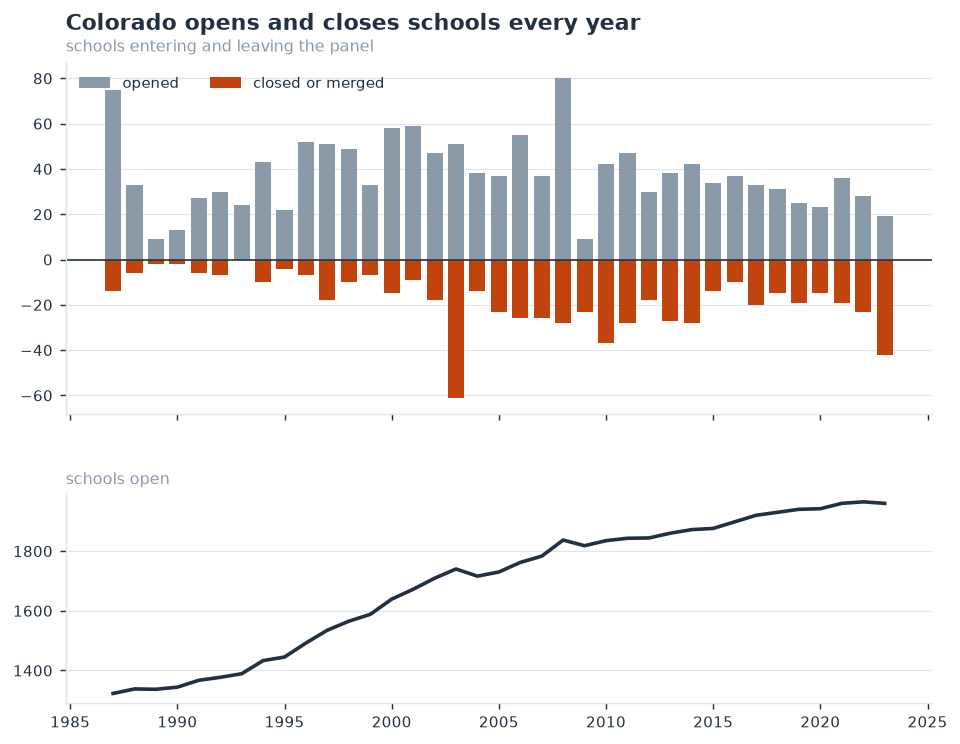

closures 1987-2023: 651   openings: 1,397   net: +746


In [3]:
first_seen = school_panel.dropna(subset=["ncessch"]).groupby("ncessch")["year"].min()
gone = last_seen[last_seen.index.isin(shut) & (last_seen < panel_end)]
per_year = pd.DataFrame({
    "opened": first_seen.value_counts(),
    "closed": gone.value_counts(),
    "open": school_panel.groupby("year")["ncessch"].nunique(),
}).fillna(0).astype(int).sort_index()
per_year = per_year.loc[1987:panel_end - 1]
per_year["net"] = per_year["opened"] - per_year["closed"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.6, 6.4), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1.2], "hspace": 0.28})
ax1.bar(per_year.index, per_year["opened"], color=MUTED, label="opened", width=0.75)
ax1.bar(per_year.index, -per_year["closed"], color=ACCENT, label="closed or merged", width=0.75)
ax1.axhline(0, color=INK, lw=0.9)
ax1.legend(loc="upper left", ncols=2)
finish(ax1, "Colorado opens and closes schools every year",
       "schools entering and leaving the panel")
ax2.plot(per_year.index, per_year["open"], color=INK, lw=2)
finish(ax2, "", "schools open")
fig.savefig(OUTPUT / "alt-fig1-openings-closures.png", bbox_inches="tight")
per_year.to_csv(OUTPUT / "alt-fig1-openings-closures.csv")
plt.show()
print(f"closures {per_year.index.min()}-{per_year.index.max()}: {per_year['closed'].sum():,}"
      f"   openings: {per_year['opened'].sum():,}   net: {per_year['net'].sum():+,}")

### A closing school is small years before it closes

The size of a school in each of the five years before it disappears, against
every school in the same year. This is the shape a closure has: not a cliff,
a slope.

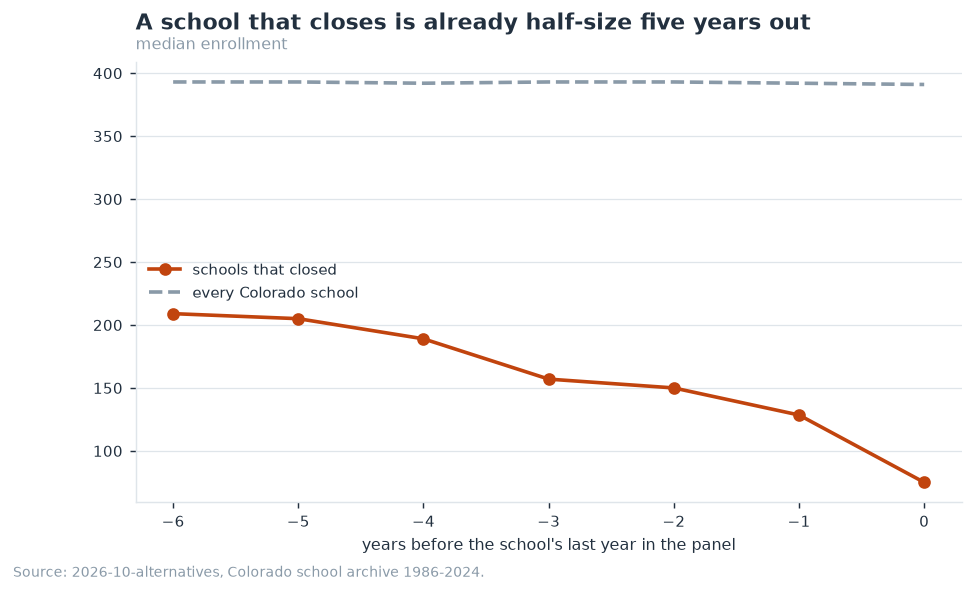

    schools  closing_median  all_median  share_of_typical
t                                                        
-6      410           209.0       393.0              0.53
-5      438           205.0       393.0              0.52
-4      473           189.0       392.0              0.48
-3      511           157.0       393.0              0.40
-2      543           150.0       393.0              0.38
-1      564           128.5       392.0              0.33
 0       39            75.0       391.0              0.19


In [4]:
last_of = gone.rename("last").reset_index()
run_up = school_panel.dropna(subset=["ncessch"]).merge(last_of, on="ncessch")
run_up = run_up[run_up["year"] <= run_up["last"]]
run_up["t"] = run_up["year"] - run_up["last"]
all_median = school_panel.groupby("year")["enrollment"].median().rename("all_median")
run_up = run_up.merge(all_median, on="year")
profile = (run_up[run_up["t"].between(-6, 0)]
           .groupby("t")
           .agg(schools=("enrollment", "count"),
                closing_median=("enrollment", "median"),
                all_median=("all_median", "median")))
profile["share_of_typical"] = profile["closing_median"] / profile["all_median"]

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(profile.index, profile["closing_median"], marker="o", color=ACCENT, lw=2,
        label="schools that closed")
ax.plot(profile.index, profile["all_median"], color=MUTED, lw=2, ls="--",
        label="every Colorado school")
ax.set_xlabel("years before the school's last year in the panel")
ax.legend(loc="center left")
finish(ax, "A school that closes is already half-size five years out",
       "median enrollment",
       "Source: 2026-10-alternatives, Colorado school archive 1986-2024.")
fig.savefig(OUTPUT / "alt-fig1b-run-up.png", bbox_inches="tight")
profile.to_csv(OUTPUT / "alt-fig1b-run-up.csv")
plt.show()
print(profile.round(2).to_string())

### What predicts a closure

A logistic model of whether a school is gone within two years, fitted on
every Colorado school-year with an enrollment. The candidates are what a
district actually looks at: how small the school is, whether it is
shrinking, how large its district is and whether the district is shrinking.
Year effects absorb the statewide cycle.

Size is entered as a log, because the difference between 150 pupils and 250
matters far more than between 850 and 950.

In [5]:
model_rows = sp[(sp["enrollment"] > 0) & sp["year"].between(1990, panel_end - 2)].copy()
model_rows = model_rows.sort_values(["ncessch", "year"])
model_rows["log_enrollment"] = np.log(model_rows["enrollment"])
model_rows["enrollment_3yr"] = (model_rows.groupby("ncessch")["enrollment"]
                                .pct_change(3, fill_method=None))
district_size = (model_rows.groupby(["year", "district_code"])["enrollment"]
                 .sum().rename("district_enrollment").reset_index()
                 .sort_values(["district_code", "year"]))
district_size["district_3yr"] = (district_size.groupby("district_code")["district_enrollment"]
                                 .pct_change(3, fill_method=None))
model_rows = model_rows.merge(district_size, on=["year", "district_code"], how="left")
model_rows["log_district"] = np.log(model_rows["district_enrollment"].clip(lower=1))

fit_rows = model_rows.dropna(subset=["log_enrollment", "enrollment_3yr",
                                     "log_district", "district_3yr", "gone_in_2"])
closure_model = smf.logit(
    "gone_in_2 ~ log_enrollment + enrollment_3yr + log_district + district_3yr + C(year)",
    data=fit_rows).fit(disp=False)
terms = ["log_enrollment", "enrollment_3yr", "log_district", "district_3yr"]
summary = pd.DataFrame({
    "coefficient": closure_model.params[terms],
    "std_error": closure_model.bse[terms],
    "p_value": closure_model.pvalues[terms],
    "odds_ratio": np.exp(closure_model.params[terms]),
})
print(f"fitted on {int(closure_model.nobs):,} school-years, "
      f"{int(fit_rows['gone_in_2'].sum()):,} closures"
      f"   pseudo R-squared {closure_model.prsquared:.3f}\n")
print(summary.round(4).to_string())
halving = np.exp(closure_model.params["log_enrollment"] * -np.log(2))
print(f"\nHalve a school's enrollment, hold the year and the district constant,"
      f"\nand it is {halving:.1f} times as likely to be gone within two years.")
summary.to_csv(OUTPUT / "alt-closure-model.csv")

fitted on 47,714 school-years, 437 closures   pseudo R-squared 0.142

                coefficient  std_error  p_value  odds_ratio
log_enrollment      -1.0252     0.0404   0.0000      0.3587
enrollment_3yr      -0.1584     0.1192   0.1840      0.8535
log_district         0.2542     0.0254   0.0000      1.2894
district_3yr        -0.3458     0.3420   0.3121      0.7077

Halve a school's enrollment, hold the year and the district constant,
and it is 2.0 times as likely to be gone within two years.


### The size at which Colorado actually closes a school

Not a rule anyone wrote down — the observed rate. For each enrollment band,
the share of school-years that turned out to be a school's last.

This is the empirical answer to "how small is too small", and it is the
number to hold BVSD's own standard against.

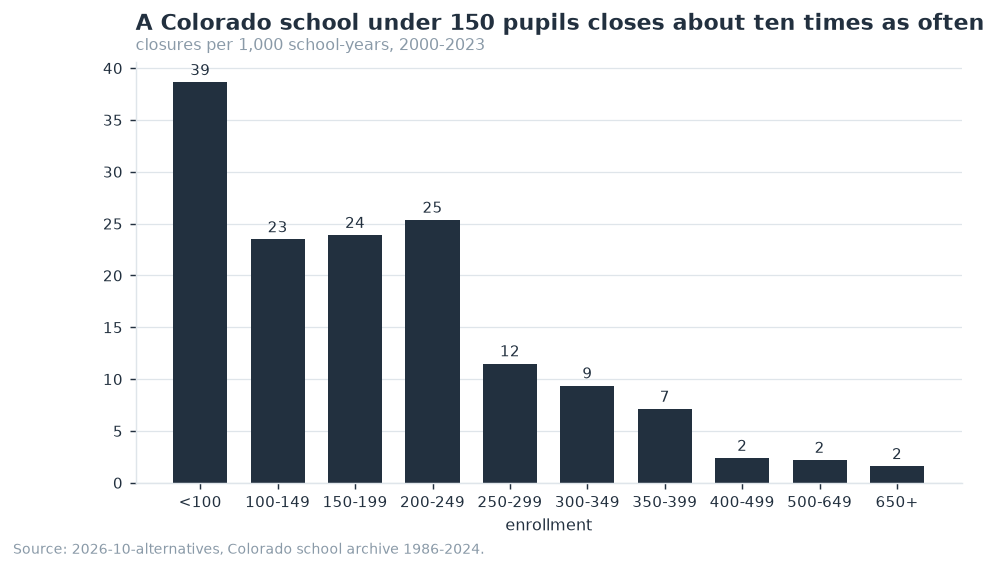

         school_years  closures  annual_rate  per_1000
band                                                  
<100             4790       185      0.03862     38.62
100-149          2642        62      0.02347     23.47
150-199          1884        45      0.02389     23.89
200-249          2406        61      0.02535     25.35
250-299          2782        32      0.01150     11.50
300-349          3308        31      0.00937      9.37
350-399          3233        23      0.00711      7.11
400-499          6293        15      0.00238      2.38
500-649          6377        14      0.00220      2.20
650+             7552        12      0.00159      1.59


In [6]:
bands = [0, 100, 150, 200, 250, 300, 350, 400, 500, 650, 10_000]
labels = ["<100", "100-149", "150-199", "200-249", "250-299", "300-349",
          "350-399", "400-499", "500-649", "650+"]
recent = model_rows[model_rows["year"].between(2000, panel_end - 2)].copy()
recent["band"] = pd.cut(recent["enrollment"], bands, labels=labels, right=False)
hazard = (recent.groupby("band", observed=True)
          .agg(school_years=("gone_in_2", "size"), closures=("gone_in_2", "sum")))
hazard["annual_rate"] = hazard["closures"] / hazard["school_years"]
hazard["per_1000"] = hazard["annual_rate"] * 1000

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar(hazard.index.astype(str), hazard["per_1000"], color=INK, width=0.7)
for i, (rate, n) in enumerate(zip(hazard["per_1000"], hazard["school_years"])):
    ax.text(i, rate + 0.7, f"{rate:.0f}", ha="center", fontsize=8.5, color=INK)
finish(ax, "A Colorado school under 150 pupils closes about ten times as often",
       "closures per 1,000 school-years, 2000-2023",
       "Source: 2026-10-alternatives, Colorado school archive 1986-2024.")
ax.set_xlabel("enrollment")
fig.savefig(OUTPUT / "alt-fig2-closure-hazard.png", bbox_inches="tight")
hazard.to_csv(OUTPUT / "alt-fig2-closure-hazard.csv")
plt.show()
print(hazard.round({"annual_rate": 5, "per_1000": 2}).to_string())

### Boulder Valley's own record

The archive's auto-labels find almost nothing in Boulder Valley: two
schools, both small special programmes. That is not because nothing
happened. It is because a label assigned from the data alone cannot tell a
closure from a rename, and the archive says so.

So this is done by hand, from the panel: every school that appears in BVSD
and then stops appearing, with the years on either side. What the data can
establish — that a building stopped taking pupils and where those pupils
went — is separated from what it cannot, which is why.

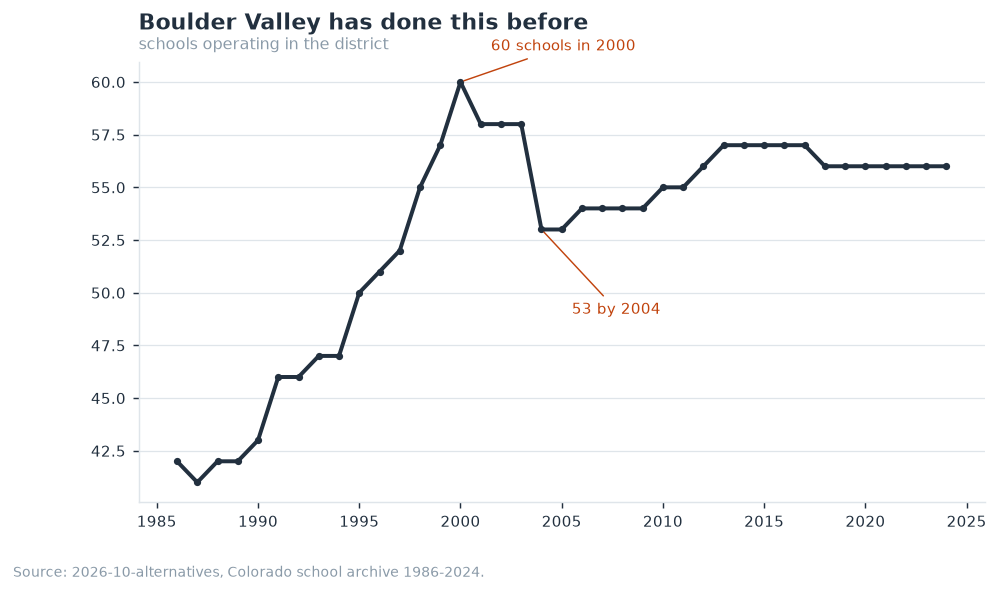

      schools  enrollment  teacher_fte
year                                  
1986       42     20751.0       1002.0
1990       43     21502.0       1141.0
1995       50     25230.0       1328.0
2000       60     27508.0       1572.0
2004       53     27926.0       1656.0
2010       55     29526.0       1682.0
2015       57     31247.0       1639.0
2020       56     29262.0       1690.0
2024       56     27991.0       1583.0


In [7]:
bvsd_panel = sp[sp["district_code"] == BVSD_CODE]
bvsd_by_year = (school_panel[school_panel["district_code"] == BVSD_CODE]
                .groupby("year")
                .agg(schools=("ncessch", "nunique"),
                     enrollment=("enrollment", "sum"),
                     teacher_fte=("teacher_fte", "sum")))
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.plot(bvsd_by_year.index, bvsd_by_year["schools"], color=INK, lw=2.2, marker="o", ms=3)
peak = bvsd_by_year["schools"].idxmax()
ax.annotate(f"{int(bvsd_by_year['schools'].max())} schools in {peak}",
            xy=(peak, bvsd_by_year["schools"].max()),
            xytext=(peak + 1.5, bvsd_by_year["schools"].max() + 1.5),
            fontsize=8.5, color=ACCENT,
            arrowprops=dict(arrowstyle="-", color=ACCENT, lw=0.8))
trough = bvsd_by_year.loc[peak:peak + 6, "schools"].idxmin()
ax.annotate(f"{int(bvsd_by_year.loc[trough, 'schools'])} by {trough}",
            xy=(trough, bvsd_by_year.loc[trough, "schools"]),
            xytext=(trough + 1.5, bvsd_by_year.loc[trough, "schools"] - 4),
            fontsize=8.5, color=ACCENT,
            arrowprops=dict(arrowstyle="-", color=ACCENT, lw=0.8))
finish(ax, "Boulder Valley has done this before",
       "schools operating in the district",
       "Source: 2026-10-alternatives, Colorado school archive 1986-2024.")
fig.savefig(OUTPUT / "alt-fig3-bvsd-schools.png", bbox_inches="tight")
bvsd_by_year.to_csv(OUTPUT / "alt-fig3-bvsd-schools.csv")
plt.show()
marks = [y for y in (1986, 1990, 1995, 2000, 2004, 2010, 2015, 2020, 2024)
         if y in bvsd_by_year.index]
print(bvsd_by_year.loc[marks].round(0).to_string())

In [8]:
# Every school that leaves the BVSD panel, with what the data can say.
bv_rows = school_panel[school_panel["district_code"] == BVSD_CODE]
bv_last = bv_rows.groupby("ncessch").agg(
    name=("school_name", "last"), first_year=("year", "min"), last_year=("year", "max"))
elsewhere = (school_panel.groupby("ncessch")["year"].max().rename("last_anywhere"))
bv_last = bv_last.join(elsewhere)
departures = bv_last[bv_last["last_year"] < panel_end].copy()

def enrollment_at(school, year):
    row = bv_rows[(bv_rows["ncessch"] == school) & (bv_rows["year"] == year)]
    return float(row["enrollment"].iloc[0]) if len(row) and pd.notna(row["enrollment"].iloc[0]) else np.nan

departures["enrollment_last"] = [enrollment_at(s, y) for s, y in
                                 zip(departures.index, departures["last_year"])]
departures["enrollment_3_before"] = [enrollment_at(s, y - 3) for s, y in
                                     zip(departures.index, departures["last_year"])]
departures["seen_after_elsewhere"] = departures["last_anywhere"] > departures["last_year"]
departures["what_the_data_shows"] = np.where(
    departures["seen_after_elsewhere"],
    "kept its NCES id outside BVSD - a transfer or a recode, not a closure",
    "leaves the panel entirely")
departures = departures.sort_values("last_year")
print(f"{len(departures)} schools leave the BVSD panel before {panel_end}\n")
print(departures[["name", "first_year", "last_year", "enrollment_3_before",
                  "enrollment_last", "what_the_data_shows"]]
      .to_string(max_colwidth=52))
departures.to_csv(OUTPUT / "alt-bvsd-departures.csv")

11 schools leave the BVSD panel before 2024

                                                name  first_year  last_year  enrollment_3_before  enrollment_last                                  what_the_data_shows
ncessch                                                                                                                                                               
080249001308                            BURKE SCHOOL        1986       1986                  NaN             43.0                            leaves the panel entirely
080249000137             VOCATIONAL TECHNICAL CENTER        1986       1995                  NaN              NaN                            leaves the panel entirely
080249000097              AURORA 7 ELEMENTARY SCHOOL        1986       2000                256.0              NaN                            leaves the panel entirely
080249000126            MAJESTIC HEIGHTS ELEM SCHOOL        1986       2000                256.0              NaN       

## 2. How many schools does the demography support?

The forecast in `2025-09-enrollments` regressed BVSD enrollment on Boulder
County's school-age population. It fits well, and it has one structural
weakness: it is fitted on **one district's own history**, so it can only
learn what Boulder has already done. If Boulder has never operated at the
staffing level the 2050s imply, the model has never seen it.

The archive makes a different fit possible. **Every Colorado district, every
year** — a panel of 180 districts over three decades, in which districts
have already lived through every demographic path Boulder is heading down.
With district fixed effects the relationship is identified from how
districts respond to *their own* population changing, not from the fact that
large counties have large districts.

Two quantities are fitted: teaching staff, and the number of schools.

In [9]:
model = panel.dropna(subset=["pop_5_17", "teacher_fte", "schools"]).copy()
model = model[(model["teacher_fte"] > 0) & (model["schools"] > 0) & (model["pop_5_17"] > 0)]
model["log_fte"] = np.log(model["teacher_fte"])
model["log_schools"] = np.log(model["schools"])
model["log_pop"] = np.log(model["pop_5_17"])
model["district"] = model["district_code"]
print(f"{len(model):,} district-years, {model['district'].nunique()} districts, "
      f"{model['year'].min()}-{model['year'].max()}")

fits = {}
for label, outcome in [("teacher FTE", "log_fte"), ("schools", "log_schools")]:
    fit = smf.ols(f"{outcome} ~ log_pop + C(district) + year", data=model).fit(
        cov_type="cluster", cov_kwds={"groups": model["district"]})
    fits[label] = fit
    print(f"\n{label}: elasticity to county 5-17 population = "
          f"{fit.params['log_pop']:.3f} "
          f"(95% CI {fit.conf_int().loc['log_pop', 0]:.3f} to "
          f"{fit.conf_int().loc['log_pop', 1]:.3f}), "
          f"within-R² {fit.rsquared:.3f}")
    # A 10% fall is 0.90, not 1.10: raising the rise to the elasticity and
    # negating it is not the same number, and it understates the fall.
    fall = (1 - 0.90 ** fit.params["log_pop"]) * 100
    print(f"   a 10% fall in the school-age population implies a "
          f"{fall:.1f}% fall in {label} "
          f"— less than proportional" if fit.params["log_pop"] < 1 else "")

elasticities = pd.DataFrame({
    label: {"elasticity": fit.params["log_pop"],
            "ci_low": fit.conf_int().loc["log_pop", 0],
            "ci_high": fit.conf_int().loc["log_pop", 1],
            "districts": model["district"].nunique(),
            "district_years": int(fit.nobs)}
    for label, fit in fits.items()}).T
elasticities.to_csv(OUTPUT / "alt-elasticities.csv")
print()
print(elasticities.round(3).to_string())

5,452 district-years, 178 districts, 1990-2024



teacher FTE: elasticity to county 5-17 population = 0.744 (95% CI 0.618 to 0.869), within-R² 0.979
   a 10% fall in the school-age population implies a 7.5% fall in teacher FTE — less than proportional

schools: elasticity to county 5-17 population = 0.424 (95% CI 0.294 to 0.554), within-R² 0.963
   a 10% fall in the school-age population implies a 4.4% fall in schools — less than proportional

             elasticity  ci_low  ci_high  districts  district_years
teacher FTE       0.744   0.618    0.869      178.0          5452.0
schools           0.424   0.294    0.554      178.0          5452.0


### Districts shed schools far more slowly than they shed children

Both elasticities are well below 1, and the school elasticity is barely half
the staffing one. A district that loses 10% of its school-age population
ends up with about 7.6% fewer teachers and **4.4% fewer schools**.

This is the single most important number for the Resilient Schools
argument, and it cuts both ways. It means a shrinking district does *not*
need to close schools in proportion to its losses — the observed behaviour
of 178 Colorado districts over thirty-five years says they do not. It also
means the schools that stay get smaller, which is the condition BVSD says it
is trying to escape.

The two facts are the trade-off. Colorado districts have, on the whole,
chosen smaller schools over fewer schools.

### Against the single-district model it replaces

`2025-09-enrollments` fitted BVSD alone. Refitting that here, on the same
data, shows what the panel buys: the single-district fit is steeper and far
less certain, because one district's history contains one path.

In [10]:
bvsd_model = model[model["district_code"] == BVSD_CODE]
comparison = []
for label, outcome in [("teacher FTE", "log_fte"), ("schools", "log_schools")]:
    single = smf.ols(f"{outcome} ~ log_pop + year", data=bvsd_model).fit()
    comparison.append({
        "outcome": label, "fit": "BVSD alone",
        "elasticity": single.params["log_pop"],
        "ci_low": single.conf_int().loc["log_pop", 0],
        "ci_high": single.conf_int().loc["log_pop", 1],
        "observations": int(single.nobs)})
    comparison.append({
        "outcome": label, "fit": "180-district panel",
        "elasticity": fits[label].params["log_pop"],
        "ci_low": fits[label].conf_int().loc["log_pop", 0],
        "ci_high": fits[label].conf_int().loc["log_pop", 1],
        "observations": int(fits[label].nobs)})
comparison = pd.DataFrame(comparison)
comparison["ci_width"] = comparison["ci_high"] - comparison["ci_low"]
print(comparison.round(3).to_string(index=False))
comparison.to_csv(OUTPUT / "alt-model-comparison.csv", index=False)

    outcome                fit  elasticity  ci_low  ci_high  observations  ci_width
teacher FTE         BVSD alone       0.913   0.598    1.229            31     0.631
teacher FTE 180-district panel       0.744   0.618    0.869          5452     0.250
    schools         BVSD alone       0.835   0.585    1.085            31     0.500
    schools 180-district panel       0.424   0.294    0.554          5452     0.260


### Boulder Valley to 2060

The SDO's Vintage 2024 forecast for Boulder County's 5-to-17 population,
put through the panel model, with the district held at its own fitted level.

The shaded band is the 95% interval on **where the relationship puts Boulder
Valley** — the uncertainty in the fitted line, given Boulder's own level.
A second, much wider interval is carried in the output CSV: the spread of
individual districts around the line, which runs from 35 to 79 schools in
2060 and is a statement about how differently districts behave, not about
Boulder.

The demographic path is a single line because the SDO publishes one.
**A reader should treat either band as the least of the uncertainty**, not
the whole of it: neither says anything about whether the SDO's migration
assumptions hold.

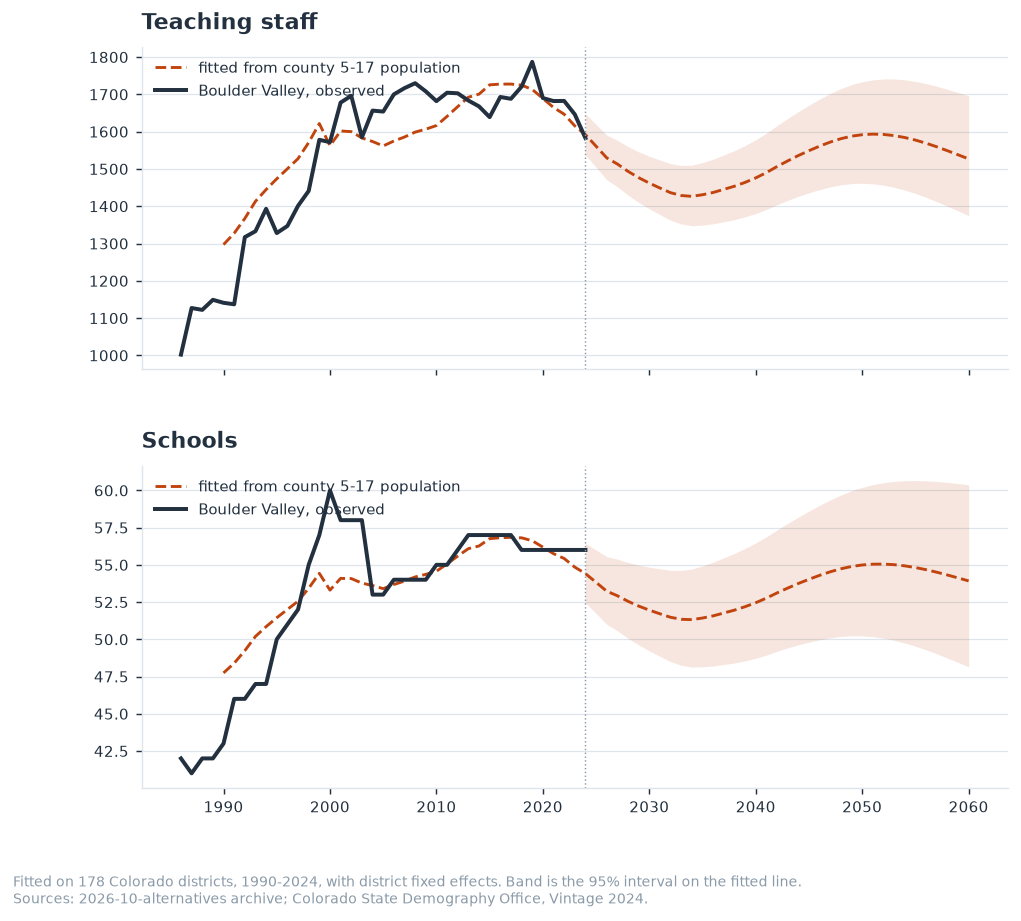

      pop_5_17  teacher_fte  teacher_fte_low  teacher_fte_high  schools  schools_low  schools_high
year                                                                                              
2024     43997       1592.0           1537.0            1648.0     54.0         52.0          56.0
2030     38685       1462.0           1393.0            1534.0     52.0         49.0          55.0
2040     38270       1476.0           1380.0            1578.0     52.0         49.0          56.0
2050     41372       1592.0           1461.0            1734.0     55.0         50.0          60.0
2060     38207       1527.0           1375.0            1696.0     54.0         48.0          60.0

Boulder Valley today (2024): 56 schools, 1,583 teacher FTE
Fitted for 2060: 54 schools (48 to 60), 1,527 teacher FTE (1,375 to 1,696)


In [11]:
future = panel[(panel["countyfips"] == BOULDER_FIPS)
               & (panel["district_code"] == BVSD_CODE)][["year", "pop_5_17", "datatype"]]
sdo_all = panel[panel["countyfips"] == BOULDER_FIPS][["year", "pop_5_17", "datatype"]].drop_duplicates()
horizon = pd.read_csv(ANALYSIS / "district-panel.csv", dtype=codes)
boulder_pop = (horizon[horizon["countyfips"] == BOULDER_FIPS][["year", "pop_5_17", "datatype"]]
               .drop_duplicates().sort_values("year"))
# The panel stops at 2024; the SDO runs to 2060. The retrieval notebook writes
# the whole forecast out for every county, which is where the later years come
# from here and in section 6.
county_pop = pd.read_csv(ANALYSIS / "county-school-age.csv", dtype={"countyfips": str})
county_pop["countyfips"] = county_pop["countyfips"].str.zfill(3)
boulder = (county_pop[county_pop["countyfips"] == BOULDER_FIPS]
           [["year", "datatype", "pop_5_17"]].sort_values("year"))

last_observed = int(model[model["district_code"] == BVSD_CODE]["year"].max())
scenario = boulder[boulder["year"].between(1990, 2060)].copy()
scenario["log_pop"] = np.log(scenario["pop_5_17"])
scenario["district_code"] = BVSD_CODE

projection = scenario[["year", "pop_5_17", "datatype", "log_pop"]].copy()
for label, outcome in [("teacher_fte", "log_fte"), ("schools", "log_schools")]:
    fit = fits["teacher FTE" if outcome == "log_fte" else "schools"]
    frame = pd.DataFrame({"log_pop": scenario["log_pop"], "year": scenario["year"],
                          "district": BVSD_CODE})
    pred = fit.get_prediction(frame).summary_frame(alpha=0.05)
    projection[label] = np.exp(pred["mean"].values)
    projection[f"{label}_low"] = np.exp(pred["mean_ci_lower"].values)
    projection[f"{label}_high"] = np.exp(pred["mean_ci_upper"].values)
    projection[f"{label}_obs_low"] = np.exp(pred["obs_ci_lower"].values)
    projection[f"{label}_obs_high"] = np.exp(pred["obs_ci_upper"].values)

actual = (school_panel[school_panel["district_code"] == BVSD_CODE]
          .groupby("year").agg(teacher_fte=("teacher_fte", "sum"),
                               schools=("ncessch", "nunique")))
projection.to_csv(OUTPUT / "alt-bvsd-projection.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(8.6, 7.4), sharex=True,
                         gridspec_kw={"hspace": 0.3})
for ax, key, title in [(axes[0], "teacher_fte", "Teaching staff"),
                       (axes[1], "schools", "Schools")]:
    fut = projection[projection["year"] >= last_observed]
    ax.fill_between(fut["year"], fut[f"{key}_low"], fut[f"{key}_high"],
                    color=ACCENT, alpha=0.13, lw=0)
    ax.plot(projection["year"], projection[key], color=ACCENT, lw=1.6, ls="--",
            label="fitted from county 5-17 population")
    obs = actual[key].dropna()
    ax.plot(obs.index, obs.values, color=INK, lw=2.2, label="Boulder Valley, observed")
    ax.axvline(last_observed, color=MUTED, lw=0.8, ls=":")
    ax.legend(loc="upper left")
    finish(ax, title, None)
axes[1].set_xlabel("")
axes[0].figure.text(0.01, -0.01,
                    "Fitted on 178 Colorado districts, 1990-2024, with district fixed effects. "
                    "Band is the 95% interval on the fitted line.\n"
                    "Sources: 2026-10-alternatives archive; Colorado State Demography Office, Vintage 2024.",
                    fontsize=7.5, color=MUTED)
fig.savefig(OUTPUT / "alt-fig4-projection.png", bbox_inches="tight")
plt.show()

marks = [y for y in (2024, 2030, 2040, 2050, 2060) if y in set(projection["year"])]
table = projection[projection["year"].isin(marks)].set_index("year")
print(table[["pop_5_17", "teacher_fte", "teacher_fte_low", "teacher_fte_high",
             "schools", "schools_low", "schools_high"]].round(0).to_string())
now = actual.loc[last_observed]
end_row = table.loc[table.index.max()]
print(f"\nBoulder Valley today ({last_observed}): {now['schools']:.0f} schools, "
      f"{now['teacher_fte']:,.0f} teacher FTE")
print(f"Fitted for {int(table.index.max())}: {end_row['schools']:.0f} schools "
      f"({end_row['schools_low']:.0f} to {end_row['schools_high']:.0f}), "
      f"{end_row['teacher_fte']:,.0f} teacher FTE "
      f"({end_row['teacher_fte_low']:,.0f} to {end_row['teacher_fte_high']:,.0f})")

### What the forecast actually says

Boulder County's school-age population falls sharply to about 2030 and is
then broadly flat for thirty years. The decline is **front-loaded, not
continuing**. Fitted against it, Boulder Valley lands at roughly three
schools fewer than today by 2060 — and the path does not keep falling.

This is the uncertainty the proposal does not present. Four closures now is
inside the range the demography supports. So is two. So is none, with
smaller schools. What the demography does **not** support is the assumption
that four closures now is the first instalment of a continuing programme.

## 3. Six levers

Closing schools is one way to respond to fewer children. It is not the only
one, and the others are not variations of it — they trade different things.
Each is set out here on its own terms, judged by what it is actually trying
to achieve, because a single scorecard would flatter the levers that happen
to optimise the column it contains.

| Lever | What it is trying to do | What it gives up |
|---|---|---|
| **1. Close** | Get every remaining school above a viable size | Buildings, and the distances they saved |
| **2. Reconfigure grades** | Fit the same children into fewer buildings without closing catchments | The elementary/middle boundary, and the transitions built around it |
| **3. Redraw boundaries** | Even out the sizes already there | Stability of who goes where |
| **4. Shrink in place** | Keep every building and every catchment | School size, and whatever depends on it |
| **5. Do nothing** | Make no decision now | Control over which schools get small |
| **6. Fill the buildings** | Raise the number of children, not cut the buildings | Control over who attends |

**Two viability bars are used throughout**, and they disagree:

- **BVSD's own**: two classes per grade, and 75% K-5 utilisation. At a
  typical class size that is roughly 50 pupils a grade, or about 300 in a
  K-5 school.
- **Colorado's observed behaviour**, from section 1: the closure rate is
  flat and low above about 300 pupils, roughly doubles between 250 and 300,
  and roughly doubles again below 150.

Where the two disagree, both are reported. Neither is treated as the answer.

In [12]:
blocks = None
try:
    import geopandas as gpd
    blocks = gpd.read_file(ANALYSIS / "bvsd-blocks.geojson")
    boundary = gpd.read_file(ANALYSIS / "bvsd-boundary.geojson")
    print(f"{len(blocks):,} census blocks inside BVSD; "
          f"{int(blocks['children'].sum()):,} children under 18 (2020 census)")
except Exception as exc:  # noqa: BLE001
    print(f"geography unavailable: {exc}")

grade_cols = [c for c in ("PK", "K") if c in bvsd_schools.columns] + \
             [str(g) for g in range(1, 13) if str(g) in bvsd_schools.columns]
bvsd_schools[grade_cols] = bvsd_schools[grade_cols].fillna(0)
bvsd_schools["enrollment"] = bvsd_schools["enrollment_total_cde"]
bvsd_schools["graded"] = bvsd_schools[[c for c in grade_cols if c != "PK"]].sum(axis=1)
high = [g for g in ("9", "10", "11", "12") if g in grade_cols]
middle = [g for g in ("6", "7", "8") if g in grade_cols]
elem = [g for g in ("K", "1", "2", "3", "4", "5") if g in grade_cols]
bvsd_schools["level"] = np.select(
    [bvsd_schools[high].sum(axis=1) > bvsd_schools["graded"] * 0.4,
     bvsd_schools[middle].sum(axis=1) > bvsd_schools["graded"] * 0.6,
     bvsd_schools[elem].sum(axis=1) > bvsd_schools["graded"] * 0.6],
    ["high", "middle", "elementary"], default="mixed")
bvsd_schools["grades_served"] = bvsd_schools[[c for c in grade_cols if c != "PK"]].gt(0).sum(axis=1)
bvsd_schools["per_grade"] = np.where(bvsd_schools["grades_served"] > 0,
                                     bvsd_schools["graded"] / bvsd_schools["grades_served"], np.nan)
print("\nBVSD, as the archive has it:")
print(bvsd_schools.groupby("level")
      .agg(schools=("school_code", "size"), pupils=("graded", "sum"),
           median_size=("graded", "median"), median_per_grade=("per_grade", "median"))
      .round(0).to_string())

# Both bars come from documents, not from this notebook. BVSD's is on slide 5
# of the work session: a "round" is a class of 25, two rounds a grade is about
# 300 pupils in a K-5 school. Colorado's is the size at which the observed
# closure rate flattens, from section 1 - and the two land in the same place,
# which is worth saying plainly: the district's standard is not unusual.
BVSD_BAR_PER_GRADE = float(says["students_per_class_round"]) * 2      # 50
BVSD_BAR_TOTAL = float(says["two_rounds_enrollment"])                 # 300
COLORADO_BAR = 300
print(f"BVSD's bar: {BVSD_BAR_PER_GRADE:.0f} a grade, {BVSD_BAR_TOTAL:.0f} a school")
print(f"Colorado's observed bar: {COLORADO_BAR} a school")
at_risk = bvsd_schools[(bvsd_schools["level"] == "elementary")
                       & (bvsd_schools["per_grade"] < BVSD_BAR_PER_GRADE)]
below_co = bvsd_schools[(bvsd_schools["level"] == "elementary")
                        & (bvsd_schools["graded"] < COLORADO_BAR)]
print(f"\nElementary schools below BVSD's two-classes-a-grade bar: {len(at_risk)}")
print(f"Elementary schools below Colorado's observed {COLORADO_BAR}-pupil bar: {len(below_co)}")

4,133 census blocks inside BVSD; 41,063 children under 18 (2020 census)

BVSD, as the archive has it:
            schools   pupils  median_size  median_per_grade
level                                                      
elementary       31   9585.0        290.0              47.0
high             12  11130.0        879.0              97.0
middle            9   4531.0        490.0             163.0
mixed             4   1975.0        580.0              74.0
BVSD's bar: 50 a grade, 300 a school
Colorado's observed bar: 300 a school

Elementary schools below BVSD's two-classes-a-grade bar: 17
Elementary schools below Colorado's observed 300-pupil bar: 16


### The district's own attendance areas

The three BVSD web maps have no export button, but the layers behind them
answer queries, so these are the district's real boundaries rather than a
nearest-school approximation — and they carry **a capacity for every
elementary area**, which the work session gives for only two.

The service was last edited **20 February 2026**. That is the right vintage:
the resolution says the February 2026 projections were what put 14
elementary schools below the bar by 2030. These are the lines the proposal
was drawn against.

In [13]:
import geopandas as gpd

areas = gpd.read_file(ANALYSIS / "bvsd-elementary-attendance-areas.geojson")
blocks = gpd.read_file(ANALYSIS / "bvsd-blocks.geojson")
areas["area_name"] = areas["area_name"].str.strip()

# The archive's enrollment, matched to the attendance area by name. The area
# names are short ("Bear Creek"); the archive's are long ("BEAR CREEK
# ELEMENTARY SCHOOL"), so the match is on the leading words and every failure
# is printed rather than dropped.
school_by_name = bvsd_schools.set_index(
    bvsd_schools["school_name"].str.upper()
    .str.replace(r"\s+(ELEMENTARY|SCHOOL|K-8|PK-8).*$", "", regex=True).str.strip())
areas["match_key"] = (areas["area_name"].str.upper()
                      .str.replace(r"\s*\((K-5|PK-8|K-8)\)", "", regex=True)
                      .str.replace("BC-", "", regex=False).str.strip())
# An elementary attendance area's capacity is for K-5. Three of these schools
# are K-8, so matching their whole roll against it invents an overcrowding
# that is not there: Aspen Creek came out at 814 pupils in 475 places. The
# enrolment matched here is K-5 only, for every school.
k5 = [g for g in ("K", "1", "2", "3", "4", "5") if g in bvsd_schools.columns]
school_by_name = school_by_name.assign(
    k5_enrollment=school_by_name[k5].sum(axis=1),
    k5_per_grade=school_by_name[k5].sum(axis=1) / len(k5))
areas["enrollment_archive"] = areas["match_key"].map(school_by_name["k5_enrollment"])
areas["per_grade_archive"] = areas["match_key"].map(school_by_name["k5_per_grade"])
areas["school_code"] = areas["match_key"].map(school_by_name["school_code"])
unmatched = areas[areas["enrollment_archive"].isna()]["area_name"].tolist()
print(f"{len(areas)} attendance areas; {areas['enrollment_archive'].notna().sum()} "
      f"matched to a school in the archive")
print("unmatched:", unmatched)

# Children per area, from the 2020 census blocks. Three bands, because they
# answer different questions: under 18 is who lives there, 5 to 17 is who is
# of school age anywhere in the system, and 5 to 10 is who an elementary
# school could actually enrol.
area_children = blocks.groupby("attendance_area")[
    ["children", "children_5_17", "children_5_10", "children_5_11"]].sum()
for band in ("children_5_17", "children_5_10", "children_5_11"):
    areas[band] = areas["area_name"].map(area_children[band])
areas["children_2020"] = areas["area_name"].map(area_children["children"])

30 attendance areas; 29 matched to a school in the archive
unmatched: ['Sanchez']


### Utilisation, at last

With a capacity per area, the district's second metric can be computed here.
It is worth being careful about which enrollment goes on top: the layer's
own `Enroll` gives a district figure of 86%, the work session says 68%, and
they are seven months and one definition apart. The archive's enrollment is
used below because it is the one this whole notebook is built on, and all
three are carried side by side so the choice is visible.

In [14]:
scored = areas[areas["capacity_gis"] > 0].copy()
scored["utilisation_archive"] = scored["enrollment_archive"] / scored["capacity_gis"]
scored["utilisation_gis"] = scored["enrollment_gis"] / scored["capacity_gis"]
scored["below_bar"] = scored["enrollment_archive"] < BVSD_BAR_TOTAL
district_util = (scored["enrollment_archive"].sum() / scored["capacity_gis"].sum())
print(f"{len(scored)} areas with a capacity")
print(f"district elementary utilisation, archive enrollment over GIS capacity: "
      f"{district_util:.0%}")
print(f"  the layer's own enrollment gives {scored['enrollment_gis'].sum() / scored['capacity_gis'].sum():.0%}")
print(f"  the work session says {says['utilization_2025_26']:.0%} across all buildings")
print(f"\nelementary schools below {BVSD_BAR_TOTAL:.0f} pupils: "
      f"{int(scored['below_bar'].sum())}  (the district counts "
      f"{int(says['schools_below_two_2025_26'])})")
show = scored.sort_values("utilisation_archive")[
    ["area_name", "capacity_gis", "enrollment_archive", "utilisation_archive",
     "per_grade_archive", "children_5_10"]]
print()
print(show.head(12).to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
scored.drop(columns="geometry").to_csv(OUTPUT / "alt-attendance-areas.csv", index=False)

27 areas with a capacity
district elementary utilisation, archive enrollment over GIS capacity: 62%
  the layer's own enrollment gives 86%
  the work session says 68% across all buildings

elementary schools below 300 pupils: 14  (the district counts 14)

     area_name  capacity_gis  enrollment_archive  utilisation_archive  per_grade_archive  children_5_10
     Gold Hill            37               10.00                 0.27               1.67           8.11
   Heatherwood           552              234.00                 0.42              39.00         436.74
     Nederland           405              172.00                 0.42              28.67         248.60
    Eisenhower           613              277.00                 0.45              46.17         541.03
          Mesa           485              230.00                 0.47              38.33         300.74
     Flatirons           337              163.00                 0.48              27.17         403.59
          Kohl  

### Does the archive agree with the district about who is small?

Two independent readings of the same district: BVSD's own attendance-area
layer, and this archive's enrollment. Where they disagree about whether a
school clears the bar, both are shown.

In [15]:
agreement = scored.assign(
    small_archive=scored["enrollment_archive"] < BVSD_BAR_TOTAL,
    small_gis=scored["enrollment_gis"] < BVSD_BAR_TOTAL)
table = pd.crosstab(agreement["small_archive"], agreement["small_gis"])
print("below the 300-pupil bar, archive (rows) against the GIS layer (columns):")
print(table.to_string())
disagree = agreement[agreement["small_archive"] != agreement["small_gis"]]
if len(disagree):
    print("\nthey disagree about:")
    print(disagree[["area_name", "enrollment_archive", "enrollment_gis",
                    "capacity_gis"]].to_string(index=False))

below the 300-pupil bar, archive (rows) against the GIS layer (columns):
small_gis      False  True 
small_archive              
False             12      1
True              10      4

they disagree about:
     area_name  enrollment_archive  enrollment_gis  capacity_gis
         Birch               277.0             376           436
    Coal Creek               283.0             467           496
      Douglass               282.0             433           491
    Eisenhower               277.0             453           613
Eldorado (K-5)               256.0             516           470
   Heatherwood               234.0             364           552
          Kohl               254.0             449           521
 Monarch (K-5)               266.0             369           423
       Sanchez                 NaN             284           301
      Whittier               269.0             394           371
          Mesa               230.0             371           485


## The six levers, on the district's own lines

Each lever is judged on what it is trying to do. There is no common
scorecard: the columns mean different things to different levers and adding
them up would be a category error.

What changes now that the boundaries and capacities are real: **utilisation
is a column**, the areas are the district's own, and a closure reassigns an
area's children to the nearest remaining school rather than to a notional
catchment.

In [16]:
located = scored[scored["school_code"].notna()].copy()
centroids = located.geometry.representative_point()
located["lat"] = centroids.y.to_numpy()
located["lon"] = centroids.x.to_numpy()

def haversine_miles(lat1, lon1, lat2, lon2):
    radius = 3958.8
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(a))

school_xy = bvsd_schools.set_index("school_code")[["latitude", "longitude"]]
located = located.join(school_xy, on="school_code")
have_xy = located["latitude"].notna()
print(f"{int(have_xy.sum())} of {len(located)} areas have a school location")

names = located["area_name"].to_numpy()
cap = located["capacity_gis"].to_numpy(dtype=float)
roll = located["enrollment_archive"].to_numpy(dtype=float)
lat = located["latitude"].to_numpy(dtype=float)
lon = located["longitude"].to_numpy(dtype=float)
between = haversine_miles(lat[:, None], lon[:, None], lat[None, :], lon[None, :])


def redistribute(open_mask):
    """Send each closed area's roll to the nearest school still open."""
    load = np.where(open_mask, roll, 0.0)
    moved = 0.0
    for i in np.flatnonzero(~open_mask):
        order = np.argsort(np.where(open_mask, between[i], np.inf))
        load[order[0]] += roll[i]
        moved += roll[i]
    return load, moved


def score(open_mask, label, gives_up):
    load, moved = redistribute(open_mask)
    open_load = load[open_mask]
    open_cap = cap[open_mask]
    return {
        "lever": label,
        "buildings": int(open_mask.sum()),
        "pupils_median": float(np.median(open_load)),
        "pupils_smallest": float(open_load.min()),
        "below_bar": int((open_load < BVSD_BAR_TOTAL).sum()),
        "over_capacity": int((open_load > open_cap).sum()),
        "utilisation": float(open_load.sum() / open_cap.sum()),
        "pupils_moved": float(moved),
        "what it gives up": gives_up,
    }

baseline = np.ones(len(located), dtype=bool)
rows = [score(baseline, "0. Today", "nothing; the bar is not met")]

closing_codes = set(proposal_actions[proposal_actions["action"] == "close"]["school_code"].dropna())
as_proposed = ~np.isin(located["school_code"].to_numpy(), list(closing_codes))
rows.append(score(as_proposed, "1a. Close, as the proposal does",
                  f"{int((~as_proposed).sum())} buildings"))

mask = baseline.copy()
while True:
    load, _ = redistribute(mask)
    failing = [i for i in np.flatnonzero(mask) if load[i] < BVSD_BAR_TOTAL]
    if not failing:
        break
    mask[min(failing, key=lambda i: load[i])] = False
rows.append(score(mask, "1b. Close until every school clears the bar",
                  f"{int((~mask).sum())} buildings"))

26 of 26 areas have a school location


### Lever 2 — Reconfigure grades

What it is trying to do: reach viable size without giving up a catchment.
What it gives up: the elementary/middle boundary.

Scored on arithmetic only — how many buildings each configuration could fill
to the district's own standard — not on whether a K-8 is good for children,
which is not a counting question.

In [17]:
elem_cols = [g for g in ("K", "1", "2", "3", "4", "5") if g in bvsd_schools.columns]
mid_cols = [g for g in ("6", "7", "8") if g in bvsd_schools.columns]
configs = {}
for label, cols in [("K-5", elem_cols), ("6-8", mid_cols), ("K-8", elem_cols + mid_cols)]:
    total = float(bvsd_schools[cols].sum().sum())
    configs[label] = {"pupils": total, "grades": len(cols),
                      "per_grade": total / len(cols),
                      "buildings_at_the_bar": np.floor(total / len(cols) / BVSD_BAR_PER_GRADE)}
configs = pd.DataFrame(configs).T
print(configs.round(1).to_string())
print(f"\nBoulder Valley has enough elementary-age children for "
      f"{int(configs.loc['K-5', 'buildings_at_the_bar'])} schools at its own")
print(f"standard. It runs {int((bvsd_schools['level'] == 'elementary').sum())}.")
print("The district does not have too many elementary schools for the number")
print("of children it has. It has them in the wrong places.")

      pupils  grades  per_grade  buildings_at_the_bar
K-5  10695.0     6.0     1782.5                  35.0
6-8   6449.0     3.0     2149.7                  42.0
K-8  17144.0     9.0     1904.9                  38.0

Boulder Valley has enough elementary-age children for 35 schools at its own
standard. It runs 31.
The district does not have too many elementary schools for the number
of children it has. It has them in the wrong places.


### Lever 3 — Redraw boundaries

Keep every building; move the lines. Unlike the earlier version of this
notebook, the redraw is now **bounded by each building's capacity** — an
even split that overfills a school is not a real option.

What it gives up: stability. A child's school changes without a closure.

In [18]:
total_roll = roll.sum()
share = cap / cap.sum()
even_by_capacity = total_roll * share
redrawn = np.minimum(even_by_capacity, cap)
rows.append({
    "lever": "3. Redraw, in proportion to capacity",
    "buildings": len(located),
    "pupils_median": float(np.median(redrawn)),
    "pupils_smallest": float(redrawn.min()),
    "below_bar": int((redrawn < BVSD_BAR_TOTAL).sum()),
    "over_capacity": 0,
    "utilisation": float(redrawn.sum() / cap.sum()),
    "pupils_moved": float(np.abs(redrawn - roll).sum() / 2),
    "what it gives up": "no buildings; children change school",
})
print(f"Today the areas run from {roll.min():.0f} to {roll.max():.0f} pupils.")
print(f"Filled in proportion to capacity they run from {redrawn.min():.0f} to "
      f"{redrawn.max():.0f}.")
print(f"{int((redrawn < BVSD_BAR_TOTAL).sum())} would still be below the bar, "
      f"against {int((roll < BVSD_BAR_TOTAL).sum())} today.")
print(f"About {np.abs(redrawn - roll).sum() / 2:,.0f} pupils would change school, "
      f"{np.abs(redrawn - roll).sum() / 2 / total_roll:.0%} of the elementary roll.")

Today the areas run from 10 to 465 pupils.
Filled in proportion to capacity they run from 12 to 433.
9 would still be below the bar, against 14 today.
About 694 pupils would change school, 9% of the elementary roll.


### Levers 4 and 5 — Shrink in place, and do nothing

The arithmetic is the same; the difference is who decides. **Shrink in
place** keeps every building and shares the loss by redrawing. **Do nothing**
lets the loss fall where it falls, so the schools that empty are the ones
whose neighbourhoods empty.

In [19]:
here = int(projection[projection["year"] == last_observed]["pop_5_17"].iloc[0])
for year in (2030, 2040, 2060):
    row = projection[projection["year"] == year]
    if not len(row):
        continue
    factor = float(row["pop_5_17"].iloc[0]) / here
    shared = np.minimum(total_roll * factor * share, cap)
    drift = roll * factor
    rows.append({
        "lever": f"4. Shrink in place, {year}",
        "buildings": len(located), "pupils_median": float(np.median(shared)),
        "pupils_smallest": float(shared.min()),
        "below_bar": int((shared < BVSD_BAR_TOTAL).sum()), "over_capacity": 0,
        "utilisation": float(shared.sum() / cap.sum()),
        "pupils_moved": float(np.abs(shared - roll).sum() / 2),
        "what it gives up": "school size, shared evenly",
    })
    rows.append({
        "lever": f"5. Do nothing, {year}",
        "buildings": len(located), "pupils_median": float(np.median(drift)),
        "pupils_smallest": float(drift.min()),
        "below_bar": int((drift < BVSD_BAR_TOTAL).sum()), "over_capacity": 0,
        "utilisation": float(drift.sum() / cap.sum()),
        "pupils_moved": 0.0,
        "what it gives up": "control over which schools get small",
    })

### Lever 6 — Fill the buildings instead of cutting them

Every lever so far takes the number of children as given and adjusts the
buildings. This one goes the other way: raise the number of children in the
buildings. Two things can do that, and the district controls one of them.

**Across the boundary.** Open enrollment already brings pupils in from
outside BVSD, and this is not hypothetical — the district runs it now and
counts it. What the count says is worth reading twice before anyone calls
this a fringe option.

**Inside it.** Housing. The district does not zone, so this is a lever it can
argue for and not one it can pull, and the SDO forecast that drives section 2
already has the county's children falling. It is scored here so that what it
would take is on the record rather than assumed impossible.

What it gives up: control over who attends, and a dependence on other
districts' losses.

In [20]:
# Section 5 reads this file again for its own purposes; it is read here too
# so the lever stands on its own rather than on a variable defined later.
oe_by_school = pd.read_csv(ANALYSIS / "oe-schools.csv")
outside = (oe_by_school[oe_by_school["level"] == "elementary"]
           .groupby("year")
           .agg(from_outside=("oe_in_from_outside", "sum"),
                roll=("total_enrollment", "sum")))
outside["share"] = outside["from_outside"] / outside["roll"]
first, last = outside.index.min(), outside.index.max()
drawn_in = float(outside.loc[last, "from_outside"])
per_year = (drawn_in - float(outside.loc[first, "from_outside"])) / (last - first)
print("elementary pupils drawn from outside the district:")
print(outside.assign(share=lambda f: (f["share"] * 100).round(1))
      .rename(columns={"share": "pct_of_roll"}).to_string())
print(f"\n{first} to {last}: the roll fell "
      f"{outside.loc[last, 'roll'] / outside.loc[first, 'roll'] - 1:+.1%} while the "
      f"pupils drawn from outside rose "
      f"{drawn_in / outside.loc[first, 'from_outside'] - 1:+.1%}.")

# The gap is what it would take to lift every school to the bar, filled into
# the schools that are short and capped at each building's capacity - a school
# already at the bar is not made larger.
short = np.clip(BVSD_BAR_TOTAL - roll, 0, None)
short = np.minimum(short, np.clip(cap - roll, 0, None))
filled = roll + short
rows.append({
    "lever": "6. Fill the buildings, close nothing",
    "buildings": len(located), "pupils_median": float(np.median(filled)),
    "pupils_smallest": float(filled.min()),
    "below_bar": int((filled < BVSD_BAR_TOTAL).sum()),
    "over_capacity": int((filled > cap).sum()),
    "utilisation": float(filled.sum() / cap.sum()),
    "pupils_moved": 0.0,
    "what it gives up": "who attends; depends on other districts' losses",
})
print(f"\npupils needed to lift every school that can reach the bar to it: "
      f"{short.sum():,.0f}")
print(f"spare capacity in the district's own buildings:                  "
      f"{np.clip(cap - roll, 0, None).sum():,.0f}")
print(f"elementary pupils it already draws from outside:                 "
      f"{drawn_in:,.0f}")
print(f"so the lever asks the district to multiply that by               "
      f"{1 + short.sum() / drawn_in:,.1f}")
print(f"at the rate it has actually managed since {first} "
      f"({per_year:+.0f} a year), that is {short.sum() / per_year:,.0f} years")
print(f"\nstill below the bar afterwards: "
      f"{int((filled < BVSD_BAR_TOTAL).sum())} — the buildings no bar of 300 "
      "can apply to")

elementary pupils drawn from outside the district:
      from_outside     roll  pct_of_roll
year                                    
2017         688.0  13003.0          5.3
2018         687.0  12846.0          5.3
2019         687.0  12676.0          5.4
2020         662.0  12466.0          5.3
2021         672.0  11272.0          6.0
2022         631.0  11321.0          5.6
2023         632.0  11070.0          5.7
2024         674.0  10807.0          6.2
2025         708.0  10682.0          6.6
2026         765.0  10427.0          7.3

2017 to 2026: the roll fell -19.8% while the pupils drawn from outside rose +11.2%.

pupils needed to lift every school that can reach the bar to it: 666
spare capacity in the district's own buildings:                  4,468
elementary pupils it already draws from outside:                 765
so the lever asks the district to multiply that by               1.9
at the rate it has actually managed since 2017 (+9 a year), that is 78 years

still below the

### What the sixth lever is and is not

**It is not a fringe option, and the district's own numbers say so.** The
elementary roll fell 19.8% between 2017 and 2026. Over the same nine years
the pupils BVSD draws from outside its boundary *rose* 11.2%, from 5.3% of
the roll to 7.3%. Everything else in this notebook is about a district
losing children. This is the one line in its accounts going the other way,
and no version of the proposal mentions it.

**The size of the gap is the surprise.** Lifting every school that can reach
300 to 300 — filling each only as far as its own building allows — takes
**666 more elementary pupils**. The district already draws **765** from
outside. The gap is smaller than a flow it is already running. In multiples,
the lever asks it to not quite double a number it has grown by a tenth while
everything else shrank.

**It is still not quick.** At the rate the district has actually managed,
about nine more pupils a year, 666 takes seventy-eight years. That is the
honest arithmetic and it is why this is a lever and not a plan: something
would have to change about how hard the district tries, and nothing in this
notebook says it can.

**So it belongs in the mix rather than as the answer.** It is the only lever
that adds children rather than rearranging them, which means it is the only
one that can be combined with any of the others without subtracting from
them: a redraw plus recruitment reaches further than either alone. Costing
that combination is beyond what this notebook has, and it is the obvious
thing the district has not put in front of its board.

In [21]:
levers = pd.DataFrame(rows)
levers.to_csv(OUTPUT / "alt-levers-summary.csv", index=False)
print(levers.round(2).to_string(index=False))

                                      lever  buildings  pupils_median  pupils_smallest  below_bar  over_capacity  utilisation  pupils_moved                                what it gives up
                                   0. Today         26         282.50            10.00         14              0         0.63          0.00                     nothing; the bar is not met
            1a. Close, as the proposal does         22         368.50            10.00          8              4         0.74        952.00                                     4 buildings
1b. Close until every school clears the bar         14         532.00           343.00          0              8         1.04       2439.00                                    12 buildings
       3. Redraw, in proportion to capacity         26         306.40            12.02          9              0         0.63        693.93            no buildings; children change school
                   4. Shrink in place, 2030         26      

### The six levers, side by side

Read down the `below_bar` column, not across the table. The levers are not
competing on one axis; they are different things to do, and the table says
what each achieves and what it costs in its own terms.

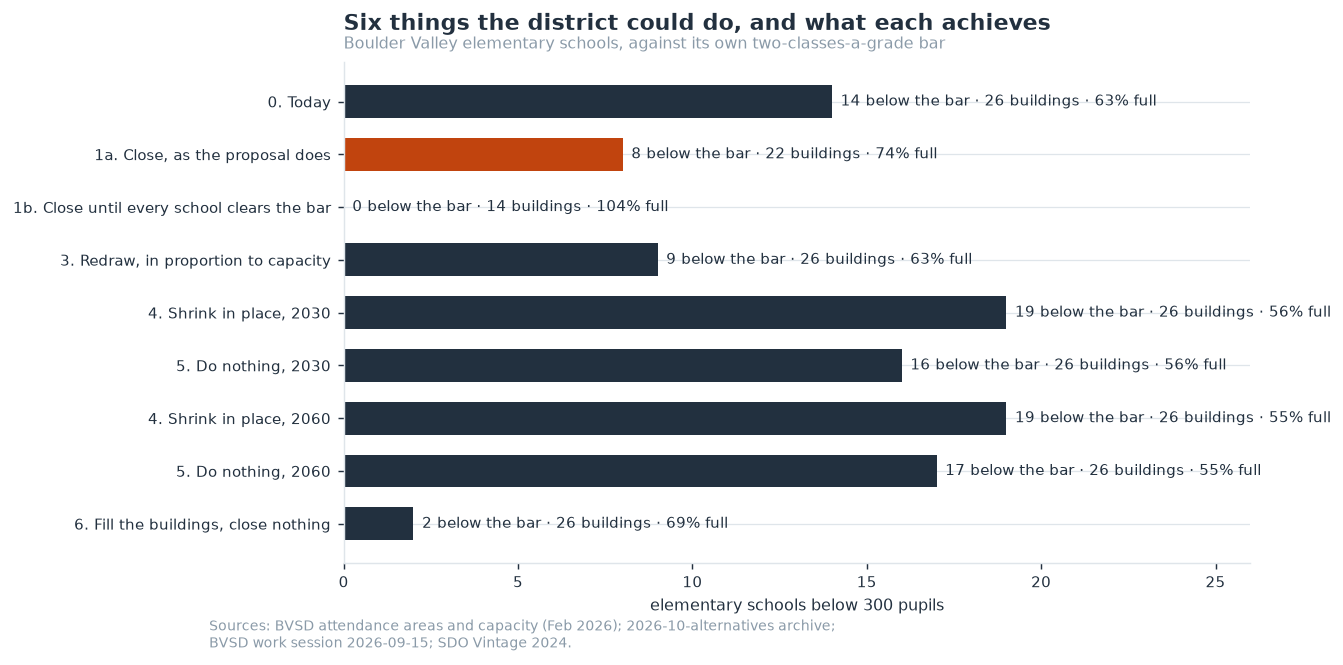

In [22]:
show = levers[~levers["lever"].str.contains("2040")].copy()
fig, ax = plt.subplots(figsize=(9.0, 5.0))
y = np.arange(len(show))[::-1]
ax.barh(y, show["below_bar"], color=[ACCENT if "Close" in l else INK
                                     for l in show["lever"]], height=0.62)
ax.set_yticks(y, show["lever"])
for i, (n, b, u) in enumerate(zip(show["below_bar"], show["buildings"], show["utilisation"])):
    ax.text(n + 0.25, y[i], f"{int(n)} below the bar · {int(b)} buildings · {u:.0%} full",
            va="center", fontsize=8.5, color=INK)
ax.set_xlim(0, 26)
ax.set_xlabel("elementary schools below 300 pupils")
finish(ax, "Six things the district could do, and what each achieves",
       f"Boulder Valley elementary schools, against its own two-classes-a-grade bar",
       "Sources: BVSD attendance areas and capacity (Feb 2026); 2026-10-alternatives archive;\n"
       "BVSD work session 2026-09-15; SDO Vintage 2024.")
fig.savefig(OUTPUT / "alt-fig5-levers.png", bbox_inches="tight")
plt.show()

### Two things the table says that the proposal does not

**Closing your way to the bar overfills the district.** Shutting schools
until every survivor clears 300 pupils takes ten closures and lands the
remaining sixteen buildings at 105% of capacity, with nine of them over.
There is no configuration of closures that reaches the district's own
enrollment standard and stays inside its own buildings.

**The mountain schools are not in this argument.** Gold Hill has 37 places
and Jamestown 19. No lever brings them to 300 pupils and none should: they
exist because the children who attend them live an hour from anywhere else.
They are counted in the "below the bar" column throughout because removing
them quietly would be worse, but nothing above proposes to touch them.

In [23]:
tiny = located[located["capacity_gis"] < 100][["area_name", "capacity_gis",
                                               "enrollment_archive"]]
print("schools no bar of 300 can apply to:")
print(tiny.to_string(index=False))
over = located[roll > cap][["area_name", "capacity_gis", "enrollment_archive"]]
print(f"\nover capacity today: {len(over)}")
print(over.to_string(index=False))
print(f"\nreaching the bar by closing alone: "
      f"{int(levers.loc[levers['lever'].str.startswith('1b'), 'buildings'].iloc[0])} buildings "
      f"at {levers.loc[levers['lever'].str.startswith('1b'), 'utilisation'].iloc[0]:.0%} "
      "of capacity")

schools no bar of 300 can apply to:
area_name  capacity_gis  enrollment_archive
Gold Hill            37                10.0
Jamestown            19                17.0

over capacity today: 0
Empty DataFrame
Columns: [area_name, capacity_gis, enrollment_archive]
Index: []

reaching the bar by closing alone: 14 buildings at 104% of capacity


### Who bears it

Which parts of the district lose a school under the proposal, by the city's
subcommunities where they apply and by municipality elsewhere.

In [24]:
closing_names = set(located.loc[~as_proposed, "area_name"])
affected = blocks[blocks["attendance_area"].isin(closing_names)]
where = (affected.groupby(affected["subcommunity"].fillna("outside the city"))
         .agg(blocks=("GEOID20", "size"), children=("children", "sum"),
              children_5_17=("children_5_17", "sum"),
              children_5_10=("children_5_10", "sum"))
         .sort_values("children_5_10", ascending=False).round(0))
print(f"areas losing their school: {', '.join(sorted(closing_names))}\n")
print(where.to_string())
for band, label in [("children", "under 18"), ("children_5_17", "aged 5 to 17"),
                    ("children_5_10", "of elementary age")]:
    print(f"{int(affected[band].sum()):6,} children {label:17s} live in an area that "
          f"loses its school — {affected[band].sum() / blocks[band].sum():.0%} "
          "of the district's")
where.to_csv(OUTPUT / "alt-who-bears-it.csv")

areas losing their school: Birch, Douglass, Flatirons, Mesa

                                   blocks  children  children_5_17  children_5_10
subcommunity                                                                     
outside the city                      428      2789           2274          929.0
Central Boulder - University Hill     126       856            594          266.0
South Boulder                          28       697            601          237.0
Southeast Boulder                      33       174            144           52.0
Central Boulder                        14        58             41           17.0
Colorado University                    14        16             14            6.0
Crossroads                              4         0              0            0.0
East Boulder                           55         2              0            0.0
 4,592 children under 18          live in an area that loses its school — 11% of the district's
 3,668 children aged 5 

## What this does not settle

- **Capacity is February 2026 and enrollment is not.** The attendance-area
  layer's own enrollment gives a district utilisation of 86%; the work
  session says 68%; the archive's enrollment over the layer's capacity gives
  70%. Capacity is a building's size and moves slowly, so it is the field
  taken from that layer; the enrollment on top of it is the archive's.
- **Redrawing is modelled as proportional to capacity, not as real lines.**
  No boundary is drawn here. What the lever establishes is the ceiling: what
  the existing buildings could hold if the children were spread across them.
  An actual redraw is constrained by geography this model does not see.
- **A closed area's children go to the nearest remaining school.** In
  practice the proposal splits them — Flatirons' area is divided at Boulder
  Canyon Drive — so the specific receiving schools here are approximate even
  though the totals are not.
- **Open enrollment is a third of the district.** BVSD says 67-70% attend
  their neighbourhood school, and the profile report puts it at 33% attending
  elsewhere in 2025. Everything above is resident-based.
- **Focus schools have no catchment.** High Peaks, Community Montessori and
  BCSIS draw district-wide; the proposal moves all three and this model
  describes them badly.
- **Nothing here is costed**, by instruction.

## The one-line version

The demography is real and the district's bar is ordinary: 300 pupils is
both BVSD's two-classes-a-grade standard and the size at which Colorado
districts actually close schools.

**What is not established is that closing buildings is the only response, or
that this set of four is the right one.** On the district's own boundaries
and capacities:

| | buildings | below the bar | pupils moved |
|---|---:|---:|---:|
| Today | 26 | 14 | — |
| The proposal | 22 | 8 | 952 |
| Redraw to capacity, close nothing | 26 | 9 | 694 |
| Fill the buildings, close nothing | 26 | 2 | 0 |

The middle two rows are the same answer by different means. The proposal
gets one more school over the bar; redrawing moves 258 fewer children and
closes nothing. Neither reaches the standard, because **closing cannot**:
closing until every school clears 300 takes twelve closures and leaves the
district at 104% of its own capacity with eight schools overfull.

The fourth row is the one nobody has costed. It reaches the bar everywhere
it can be reached and moves nobody, because it adds children rather than
rearranging them — and it needs 666 of them, against the 765 the district
already draws from outside its boundary. It would take decades at the rate
the district manages now, so it is not a quick answer. It is the only one on
the list that is not, in principle, out of reach.

The bar cannot be met by closing. It can be approached several ways, and the
board was shown one of them.

## 4. Why a school is small

Every catchment model above assumed a child attends the school whose area
they live in. A third of Boulder Valley's pupils do not, and the district
publishes exactly who: an Enrollment Pattern Matrix per level, every
attendance area against every school. All 69 school rows in those three
matrices rebuild to their printed totals exactly, so what follows is the
district's own arithmetic rather than an inference from it.

That makes a distinction the proposal never draws. **A school can be small
because few children live in its area, or because the children who live
there go somewhere else.** Those are different problems. Only the first is
demographic, and only the first is fixed by closing a building.

In [25]:
oe_areas = pd.read_csv(ANALYSIS / "oe-areas.csv")
oe_schools = pd.read_csv(ANALYSIS / "oe-schools.csv")
oe_flows = pd.read_csv(ANALYSIS / "oe-flows.csv")
OE_NOW = int(oe_areas["year"].max())       # 2026, the year the proposal is about

el_areas = oe_areas[(oe_areas["level"] == "elementary")
                    & (oe_areas["year"] == OE_NOW)].dropna(
    subset=["pct_staying_in_neighborhood_school"]).copy()
el_schools = oe_schools[(oe_schools["level"] == "elementary")
                        & (oe_schools["year"] == OE_NOW)]
# An area shared between two schools is printed with an asterisk ("Mesa*"),
# and the school row is not. Matching on the bare name keeps those areas in.
el_areas["key"] = el_areas["attendance_area"].str.rstrip("*").str.strip()
el_schools = el_schools.assign(key=el_schools["school"].str.rstrip("*").str.strip())
paired = el_areas.merge(
    el_schools[["key", "school", "total_enrollment", "attending_neighborhood_school",
                "oe_in_from_district", "oe_in_from_outside"]],
    on="key", how="inner")
paired["below_bar"] = paired["total_enrollment"] < BVSD_BAR_TOTAL
paired["children_leaving"] = paired["oe_out_of_area"]
paired["if_all_stayed"] = paired["students_living_in_area"]
# Shared areas are printed with an asterisk ("Mesa*"), which the closure list
# does not carry.
paired["closing"] = (paired["attendance_area"].str.rstrip("*")
                     .isin({n.rstrip("*") for n in closing_names}))

print(f"{len(paired)} elementary areas with both a resident count and a school")
print(f"below the bar on the district's own 2025-26 enrollment: "
      f"{int(paired['below_bar'].sum())}")
print()
print(paired.sort_values("pct_staying_in_neighborhood_school")
      [["attendance_area", "students_living_in_area",
        "pct_staying_in_neighborhood_school", "children_leaving",
        "total_enrollment", "below_bar", "closing"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

25 elementary areas with both a resident count and a school
below the bar on the district's own 2025-26 enrollment: 15

attendance_area  students_living_in_area  pct_staying_in_neighborhood_school  children_leaving  total_enrollment  below_bar  closing
        Sanchez                   642.00                                0.35            378.00            276.00       True    False
      Columbine                   501.00                                0.44            252.00            313.00      False    False
     Crest View                   657.00                                0.46            337.00            330.00      False    False
    Monarch K-8                   310.00                                0.48            152.00            264.00       True    False
       Whittier                   287.00                                0.53            127.00            257.00       True    False
      Jamestown                    11.00                                0.55      

### The two kinds of small school

On one axis, how many children live in the area. On the other, how many of
them stay. A school in the bottom left is small because its neighbourhood
has emptied. A school in the bottom right is small because its neighbourhood
chose otherwise.

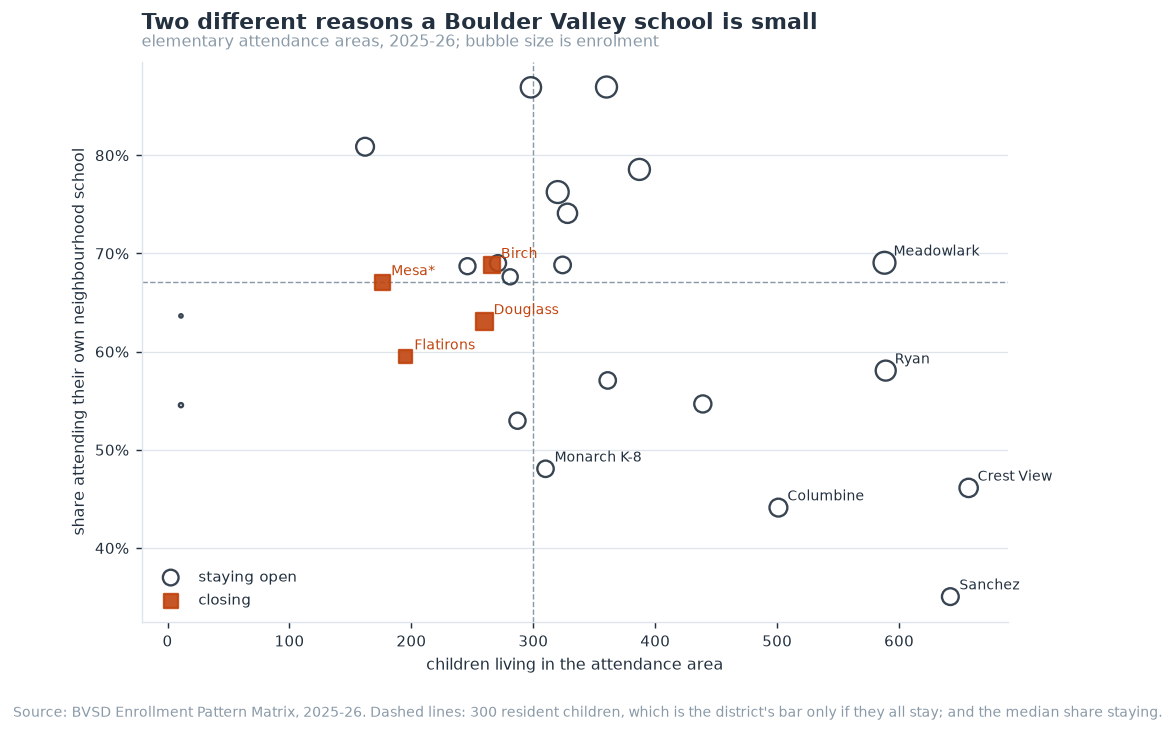

In [26]:
fig, ax = plt.subplots(figsize=(8.6, 5.6))
for closing, marker, label in [(False, "o", "staying open"), (True, "s", "closing")]:
    subset = paired[paired["closing"] == closing]
    ax.scatter(subset["students_living_in_area"],
               subset["pct_staying_in_neighborhood_school"],
               s=subset["total_enrollment"] / 3.2,
               facecolor=ACCENT if closing else "none",
               edgecolor=ACCENT if closing else INK, linewidth=1.3,
               marker=marker, label=label, zorder=3, alpha=0.9)
ax.axhline(paired["pct_staying_in_neighborhood_school"].median(), color=MUTED,
           lw=0.8, ls="--")
ax.axvline(BVSD_BAR_TOTAL, color=MUTED, lw=0.8, ls="--")
for _, row in paired.iterrows():
    if (row["pct_staying_in_neighborhood_school"] < 0.5
            or row["students_living_in_area"] > 480 or row["closing"]):
        ax.annotate(row["attendance_area"],
                    (row["students_living_in_area"],
                     row["pct_staying_in_neighborhood_school"]),
                    xytext=(5, 4), textcoords="offset points", fontsize=7.8,
                    color=ACCENT if row["closing"] else INK)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("children living in the attendance area")
ax.set_ylabel("share attending their own neighbourhood school")
ax.legend(loc="lower left")
finish(ax, "Two different reasons a Boulder Valley school is small",
       "elementary attendance areas, 2025-26; bubble size is enrolment",
       "Source: BVSD Enrollment Pattern Matrix, 2025-26. Dashed lines: 300 resident "
       "children, which is the district's bar only if they all stay; and the "
       "median share staying.")
fig.savefig(OUTPUT / "alt-fig6-why-small.png", bbox_inches="tight")
paired.to_csv(OUTPUT / "alt-why-small.csv", index=False)
plt.show()

### What that changes

The closing schools are in areas with materially fewer children — a median
of 228 against 324 for those staying open — which is the demographic case,
and it holds. Their retention is close to everyone else's.

What does not follow is that they are where the district's missing pupils
are. **The five areas whose families leave most are all staying open**, and
between them 1,246 children live in those areas and attend school somewhere
else. Sanchez alone has 642 children living in its area, 276 enrolled in its
school, and 378 going elsewhere: the largest single pool of pupils the
district is not capturing, in a school that is below the bar and not on the
list.

In [27]:
groups = paired.groupby("closing").agg(
    areas=("attendance_area", "size"),
    median_children=("students_living_in_area", "median"),
    median_staying=("pct_staying_in_neighborhood_school", "median"),
    median_enrollment=("total_enrollment", "median"))
groups.index = ["staying open", "closing"]
print(groups.round(2).to_string())

leavers = paired.nsmallest(5, "pct_staying_in_neighborhood_school")
print(f"\nThe five areas whose families leave most:")
print(leavers[["attendance_area", "students_living_in_area",
               "pct_staying_in_neighborhood_school", "children_leaving",
               "total_enrollment", "closing"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print(f"\nBetween them, {int(leavers['children_leaving'].sum()):,} children live in "
      "these five areas and attend a school\nsomewhere else. None of the five is "
      "being closed.")
print(f"\nAcross every elementary area, "
      f"{int(paired['children_leaving'].sum()):,} children open-enrol out of their "
      f"own school,\nagainst {int(paired['total_enrollment'].sum()):,} elementary "
      "places filled in total.")

              areas  median_children  median_staying  median_enrollment
staying open     21            324.0            0.68              288.0
closing           4            227.5            0.65              241.5

The five areas whose families leave most:
attendance_area  students_living_in_area  pct_staying_in_neighborhood_school  children_leaving  total_enrollment  closing
        Sanchez                   642.00                                0.35            378.00            276.00    False
      Columbine                   501.00                                0.44            252.00            313.00    False
     Crest View                   657.00                                0.46            337.00            330.00    False
    Monarch K-8                   310.00                                0.48            152.00            264.00    False
       Whittier                   287.00                                0.53            127.00            257.00    False

Between 

## 5. Has this been going on long?

Section 4 is one year. The district has published the same matrix every year
since 2016-17, so the question the proposal turns on can be answered rather
than assumed: **are the areas losing their families losing them because of
the proposal, or had they been losing them for a decade already?**

Neither. The share of Boulder Valley's elementary children attending their
own neighbourhood school sat flat at about 70% from 2017 to 2020. It fell
four points in 2021, recovered half of that in 2022, and has fallen in every
year since - to 62.6%, six points below where it started and still going
down. The proposal did not start it, and a decade of steady decline is not
what the record shows either.

In [28]:
el = oe_areas[oe_areas["level"] == "elementary"].copy()
district = el.groupby("year").agg(
    areas=("attendance_area", "size"),
    living=("students_living_in_area", "sum"),
    staying=("staying_in_neighborhood_school", "sum"),
    leaving=("oe_out_of_area", "sum"))
district["share_staying"] = district["staying"] / district["living"]
print(district.assign(share_staying=lambda d: (d["share_staying"] * 100).round(1))
      .to_string())

first, last = district.index.min(), district.index.max()
base, now = district.loc[first], district.loc[last]
held = now["living"] * base["share_staying"]
print(f"\nBetween {first} and {last} the children living in an elementary "
      f"attendance area fell\nby {base['living'] - now['living']:,.0f}, from "
      f"{base['living']:,.0f} to {now['living']:,.0f} — "
      f"{(now['living'] / base['living'] - 1) * -100:.0f}%.")
print(f"Over the same years the roll of the neighbourhood schools fell by "
      f"{base['staying'] - now['staying']:,.0f},\nfrom {base['staying']:,.0f} to "
      f"{now['staying']:,.0f} — {(now['staying'] / base['staying'] - 1) * -100:.0f}%.")
print(f"\nHad the {base['share_staying']:.1%} share of {first} held, "
      f"{now['living']:,.0f} children would fill {held:,.0f} places.")
print(f"  demography:      {base['staying'] - held:7,.0f} pupils "
      f"({(base['staying'] - held) / (base['staying'] - now['staying']):.0%})")
print(f"  families leaving:{held - now['staying']:8,.0f} pupils "
      f"({(held - now['staying']) / (base['staying'] - now['staying']):.0%})")

      areas   living  staying  leaving  share_staying
year                                                 
2017     29  12296.0   8570.0   3501.0           69.7
2018     30  12149.0   8457.0   3429.0           69.6
2019     30  11987.0   8396.0   3328.0           70.0
2020     30  11804.0   8262.0   3349.0           70.0
2021     30  10584.0   7000.0   3370.0           66.1
2022     30  10675.0   7325.0   3131.0           68.6
2023     30  10422.0   7079.0   3100.0           67.9
2024     30  10116.0   6711.0   3155.0           66.3
2025     30   9960.0   6411.0   3265.0           64.4
2026     30   9645.0   6040.0   3325.0           62.6

Between 2017 and 2026 the children living in an elementary attendance area fell
by 2,651, from 12,296 to 9,645 — 22%.
Over the same years the roll of the neighbourhood schools fell by 2,530,
from 8,570 to 6,040 — 30%.

Had the 69.7% share of 2017 held, 9,645 children would fill 6,722 places.
  demography:        1,848 pupils (73%)
  families leaving

### Which is to say

The decline in neighbourhood-school enrolment is **not all demographic**.
About a quarter of it is children who exist, who live in Boulder Valley, and
who go to school somewhere other than the school their address is assigned
to. Closing a building does not recover them, and the proposal's own case —
that there are not enough children — is the three-quarters, not the whole.

The turn is 2021, and nothing since has turned it back. Before it the share
held while the child population was already falling; after it the schools
empty faster than the neighbourhoods do, which is what the widening gap in
the right-hand panel is.

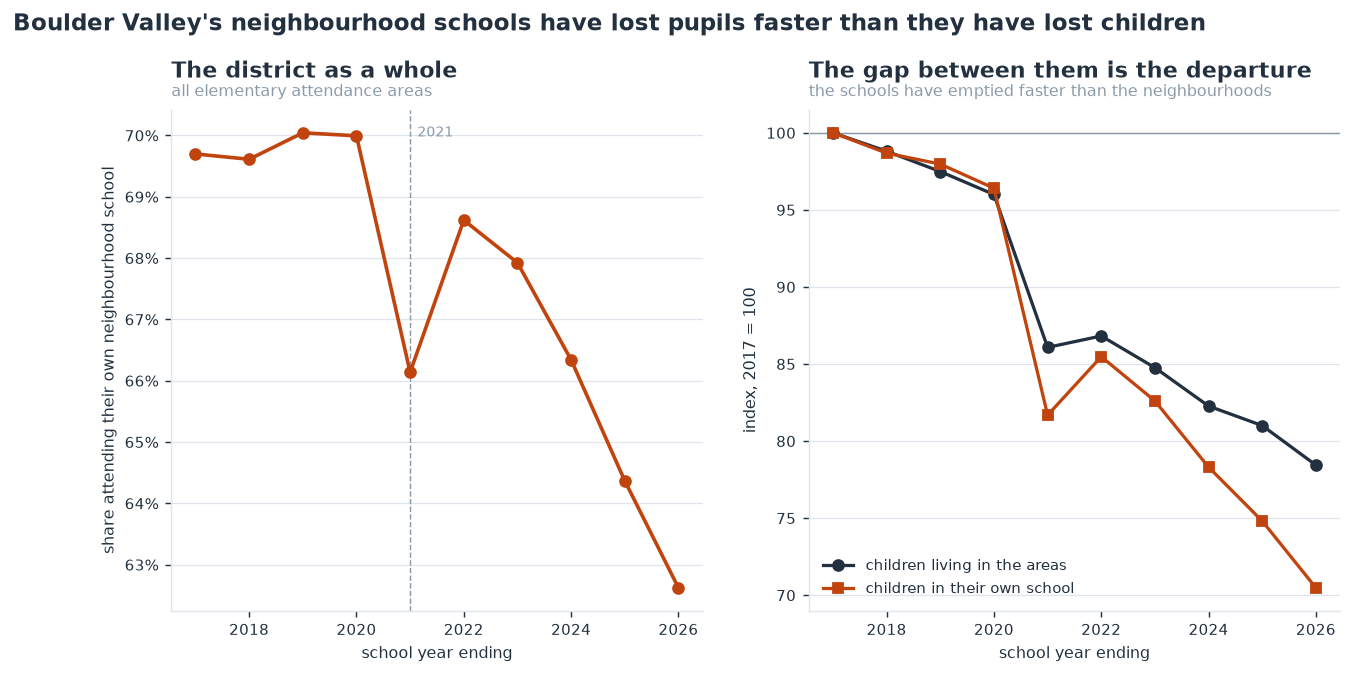

In [29]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.6, 5.0))

left.plot(district.index, district["share_staying"] * 100, marker="o",
          color=ACCENT, lw=2, zorder=3)
left.axvline(2021, color=MUTED, lw=0.8, ls="--")
left.annotate("2021", (2021, district["share_staying"].max() * 100),
              xytext=(4, -2), textcoords="offset points", fontsize=8, color=MUTED)
left.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
left.set_xlabel("school year ending")
left.set_ylabel("share attending their own neighbourhood school")
finish(left, "The district as a whole", "all elementary attendance areas")

indexed = district[["living", "staying"]] / district[["living", "staying"]].iloc[0] * 100
right.plot(indexed.index, indexed["living"], marker="o", color=INK, lw=1.8,
           label="children living in the areas", zorder=3)
right.plot(indexed.index, indexed["staying"], marker="s", color=ACCENT, lw=1.8,
           label="children in their own school", zorder=3)
right.axhline(100, color=MUTED, lw=0.8)
right.set_xlabel("school year ending")
right.set_ylabel(f"index, {first} = 100")
right.legend(loc="lower left")
finish(right, "The gap between them is the departure",
       "the schools have emptied faster than the neighbourhoods")
fig.suptitle("Boulder Valley's neighbourhood schools have lost pupils faster "
             "than they have lost children", fontsize=13, fontweight="bold",
             x=0.02, ha="left", y=1.03)
fig.savefig(OUTPUT / "alt-fig7-oe-trend.png", bbox_inches="tight")
district.to_csv(OUTPUT / "alt-oe-trend.csv")
plt.show()

### Area by area

The district figure hides the spread. Ranked by how much of their catchment
each area has lost since 2017, and marked with whether the proposal closes
the school.

In [30]:
wide = el.pivot_table(index="attendance_area", columns="year",
                      values="pct_staying_in_neighborhood_school")
wide = wide.dropna(subset=[first, last])
change = pd.DataFrame({
    "share_2017": wide[first], "share_2026": wide[last],
    "change": wide[last] - wide[first],
    "children_2026": el[el["year"] == last].set_index("attendance_area")[
        "students_living_in_area"],
    "leaving_2026": el[el["year"] == last].set_index("attendance_area")[
        "oe_out_of_area"]})
change["closing"] = [n.rstrip("*") in {c.rstrip("*") for c in closing_names}
                     for n in change.index]
change = change.sort_values("change")
print(change.assign(
    share_2017=lambda d: (d["share_2017"] * 100).round(0),
    share_2026=lambda d: (d["share_2026"] * 100).round(0),
    change=lambda d: (d["change"] * 100).round(0)).to_string())
change.to_csv(OUTPUT / "alt-oe-change.csv")

falling = change[change["change"] < -0.05]
print(f"\n{len(falling)} of {len(change)} areas have lost more than five points "
      f"of their catchment since {first}.")
print(f"Of the {int(change['closing'].sum())} areas whose school the proposal "
      f"closes, {int(falling['closing'].sum())} are among them.")
print(f"\nThe five that have lost most, and whether they close:")
print(falling.head(5)[["share_2017", "share_2026", "children_2026",
                       "leaving_2026", "closing"]]
      .assign(share_2017=lambda d: (d["share_2017"] * 100).round(0),
              share_2026=lambda d: (d["share_2026"] * 100).round(0))
      .to_string())

                               share_2017  share_2026  change  children_2026  leaving_2026  closing
attendance_area                                                                                    
Gold Hill                           100.0        64.0   -36.0           11.0           3.0    False
Monarch K-8                          73.0        48.0   -25.0          310.0         152.0    False
Whittier                             76.0        53.0   -23.0          287.0         127.0    False
Douglass                             78.0        63.0   -15.0          260.0          92.0     True
Eldorado K-8                         83.0        69.0   -15.0          246.0          71.0    False
Columbine                            58.0        44.0   -14.0          501.0         252.0    False
Crest View                           60.0        46.0   -13.0          657.0         337.0    False
Heatherwood                          81.0        68.0   -13.0          281.0          81.0    False


### How many of an area's children the district has at all

The matrices count pupils; the census counts children. Put together they
say something neither does alone: **what share of an attendance area's
elementary-age children are enrolled in a Boulder Valley school of any
kind.** The rest are at private schools, at charters outside the district,
at home, or not yet in school.

The two have to be read at the same moment to mean anything, and here they
can be. The census was taken in April 2020 and the 2019-20 matrix describes
that same school year, so this is one comparison rather than a six-year
extrapolation.

What it is not is exact. A Colorado child is five by the October kindergarten
starts, so by the April of a census the K-5 roll spans ages five to eleven,
with the years at each end only partly in it. Both bands are carried below,
and the gap between them is the honest width of the answer: **the level moves
with the band and the ranking does not.**

In [31]:
CENSUS_YEAR = 2020
census_year_areas = oe_areas[(oe_areas["level"] == "elementary")
                             & (oe_areas["year"] == CENSUS_YEAR)]
reach = (areas[["area_name", "children_5_10", "children_5_11"]]
         .merge(census_year_areas[["attendance_area", "students_living_in_area"]],
                left_on="area_name", right_on="attendance_area", how="inner")
         .dropna(subset=["children_5_10"]))
reach["share_of_5_10"] = reach["students_living_in_area"] / reach["children_5_10"]
reach["share_of_5_11"] = reach["students_living_in_area"] / reach["children_5_11"]
reach = reach.sort_values("share_of_5_11")
print(f"{len(reach)} areas with both a census count and a matrix count in "
      f"{CENSUS_YEAR}")
for band in ("5_10", "5_11"):
    children = reach[f"children_{band}"].sum()
    print(f"district-wide, against ages {band.replace('_', ' to ')}: "
          f"{reach['students_living_in_area'].sum():,.0f} pupils against "
          f"{children:,.0f} children — "
          f"{reach['students_living_in_area'].sum() / children:.0%}")
print(f"\nThe two bands rank the areas the same way: Spearman "
      f"{reach['share_of_5_10'].corr(reach['share_of_5_11'], method='spearman'):.3f}")
print()
print(reach[["area_name", "children_5_10", "children_5_11",
             "students_living_in_area", "share_of_5_10", "share_of_5_11"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
reach.to_csv(OUTPUT / "alt-district-reach.csv", index=False)

22 areas with both a census count and a matrix count in 2020
district-wide, against ages 5 to 10: 9,560 pupils against 11,166 children — 86%
district-wide, against ages 5 to 11: 9,560 pupils against 13,178 children — 73%

The two bands rank the areas the same way: Spearman 0.982

  area_name  children_5_10  children_5_11  students_living_in_area  share_of_5_10  share_of_5_11
  Jamestown          25.67          30.46                    14.00           0.55           0.46
  Flatirons         403.59         477.48                   233.00           0.58           0.49
  Gold Hill           8.11           9.65                     5.00           0.62           0.52
Heatherwood         436.74         521.60                   313.00           0.72           0.60
    Emerald         473.13         568.71                   372.00           0.79           0.65
 Meadowlark         679.95         796.59                   532.00           0.78           0.67
   Foothill         685.88         824.4

### What that adds

The spread is the finding. An area where the district holds a small share of
the children living in it has a pool it is not reaching, and that pool is
invisible to every enrollment-based measure in this folder — including the
district's own. It is a different quantity from section 4's retention, which
asks where the district's own pupils go: a school can keep most of its
enrolled residents and still sit in a neighbourhood whose children are
largely elsewhere.

## 6. Is Boulder unusual?

Section 2 fitted the model on 178 districts and applied it to one. It can be
applied to all of them, and that answers a question the proposal keeps
implying and never tests: **is Boulder Valley's position unusual, or is it
what most of Colorado is living through?**

Two different questions, and they want different arithmetic.

1. **How big an adjustment is coming?** The panel model, run forward on each
   district's own county forecast to 2060. This is a within-district
   question and the fixed effects are exactly right for it.
2. **Is the district out of line now?** Fixed effects cannot answer this —
   they absorb the level, which is the thing being asked about. So the
   second reading is cross-sectional: how many schools a district runs for
   the pupils it has, against what districts of that size run.

In [32]:
county_forecast = pd.read_csv(ANALYSIS / "county-school-age.csv",
                              dtype={"countyfips": str})
county_forecast["countyfips"] = county_forecast["countyfips"].str.zfill(3)

BASE_YEAR = int(model["year"].max())
HORIZON = 2060
base = (model[model["year"] == BASE_YEAR]
        [["district_code", "district_name", "countyfips", "teacher_fte",
          "schools", "enrollment", "pop_5_17"]].copy())
horizon_pop = (county_forecast[county_forecast["year"] == HORIZON]
               [["countyfips", "pop_5_17"]].rename(columns={"pop_5_17": "pop_2060"}))
steady = base.merge(horizon_pop, on="countyfips", how="inner")
steady["pop_change"] = steady["pop_2060"] / steady["pop_5_17"] - 1

# With district fixed effects the level drops out of a ratio, so each
# district's own path needs only the elasticity and the years between.
for label, key, outcome in [("teacher FTE", "teacher_fte", "log_fte"),
                            ("schools", "schools", "log_schools")]:
    fit = fits[label]
    beta, trend = fit.params["log_pop"], fit.params["year"]
    ratio = (steady["pop_2060"] / steady["pop_5_17"]) ** beta
    steady[f"{key}_2060_demography"] = steady[key] * ratio
    steady[f"{key}_2060"] = steady[key] * ratio * np.exp(trend * (HORIZON - BASE_YEAR))
steady["schools_change"] = steady["schools_2060"] / steady["schools"] - 1
steady["fte_change"] = steady["teacher_fte_2060"] / steady["teacher_fte"] - 1
steady["schools_change_demography"] = (steady["schools_2060_demography"]
                                       / steady["schools"] - 1)
print(f"{len(steady)} districts carried to {HORIZON} on their own county's forecast")
print(f"county 5-to-17 population change to {HORIZON}: "
      f"{steady['pop_change'].min():+.0%} to {steady['pop_change'].max():+.0%}, "
      f"median {steady['pop_change'].median():+.0%}")
print(f"implied school count change:  "
      f"{steady['schools_change'].min():+.0%} to {steady['schools_change'].max():+.0%}, "
      f"median {steady['schools_change'].median():+.0%}")
print(f"  on demography alone, without the fitted trend: median "
      f"{steady['schools_change_demography'].median():+.0%}")
steady.to_csv(OUTPUT / "alt-statewide-steady-state.csv", index=False)

178 districts carried to 2060 on their own county's forecast
county 5-to-17 population change to 2060: -62% to +47%, median -9%
implied school count change:  -30% to +24%, median +1%
  on demography alone, without the fitted trend: median -4%


### The adjustment Boulder faces is ordinary

Ranked by how much of its school count the model says a district ends up
shedding by 2060. Boulder Valley's place in that ranking is the answer to
the first question.

In [33]:
steady = steady.sort_values("schools_change")
steady["rank"] = range(1, len(steady) + 1)
bvsd_row = steady[steady["district_code"] == BVSD_CODE].iloc[0]
print(f"Boulder Valley: {bvsd_row['schools']:.0f} schools in {BASE_YEAR}, "
      f"{bvsd_row['schools_2060']:.0f} in {HORIZON} "
      f"({bvsd_row['schools_change']:+.0%}), county 5-to-17 "
      f"{bvsd_row['pop_change']:+.0%}")
print(f"  on demography alone, without the fitted trend: "
      f"{bvsd_row['schools_2060_demography']:.0f} schools "
      f"({bvsd_row['schools_change_demography']:+.0%})")
print(f"  rank {int(bvsd_row['rank'])} of {len(steady)} — "
      f"{int((steady['schools_change'] < bvsd_row['schools_change']).sum())} "
      f"Colorado districts face a larger contraction")
shrinking = steady[steady["schools_change"] < -0.02]
print(f"\n{len(shrinking)} of {len(steady)} districts shed schools at all on this "
      f"model; {int((steady['pop_change'] < 0).sum())} are in a county whose "
      f"5-to-17 population falls.")
print("\nthe ten facing the largest contraction:")
print(steady.head(10)[["district_name", "schools", "schools_2060", "pop_change",
                       "schools_change", "fte_change"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print("\nthe five largest districts, for scale:")
print(steady.nlargest(5, "enrollment")[["district_name", "enrollment", "schools",
                                        "schools_2060", "pop_change",
                                        "schools_change"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

Boulder Valley: 56 schools in 2024, 55 in 2060 (-1%), county 5-to-17 -13%
  on demography alone, without the fitted trend: 53 schools (-6%)
  rank 73 of 178 — 72 Colorado districts face a larger contraction

71 of 178 districts shed schools at all on this model; 116 are in a county whose 5-to-17 population falls.

the ten facing the largest contraction:
                       district_name  schools  schools_2060  pop_change  schools_change  fte_change
                        Rangely RE-4     2.00          1.39       -0.62           -0.30       -0.48
                         Meeker RE-1     3.00          2.09       -0.62           -0.30       -0.48
                          Trinidad 1     3.00          2.32       -0.52           -0.23       -0.38
               Primero Reorganized 2     2.00          1.55       -0.52           -0.23       -0.38
                Hoehne Reorganized 3     1.00          0.77       -0.52           -0.23       -0.38
               Aguilar Reorganized 6     2.0

### And its schools are ordinary too

The cross-sectional question. Fixed effects cannot answer it, and neither
can a single line fitted across the whole state: Colorado's districts run
from 25 pupils to 90,450, and over that range a log-log fit puts Denver 60%
above its own norm, which is a statement about the functional form and not
about Denver.

So no form at all. Average school size against district size, in bands, and
then Boulder Valley against the districts that are actually comparable to it.

In [34]:
norm = base[(base["enrollment"] > 0) & (base["schools"] > 0)].copy()
norm["average_school"] = norm["enrollment"] / norm["schools"]
edges = [0, 300, 1_000, 3_000, 10_000, 30_000, np.inf]
names = ["under 300", "300-999", "1k-3k", "3k-10k", "10k-30k", "30k and over"]
norm["band"] = pd.cut(norm["enrollment"], edges, labels=names, right=False)
bands = norm.groupby("band", observed=True).agg(
    districts=("district_code", "size"),
    median_enrollment=("enrollment", "median"),
    median_schools=("schools", "median"),
    median_school_size=("average_school", "median"),
    lower_quartile=("average_school", lambda s: s.quantile(0.25)),
    upper_quartile=("average_school", lambda s: s.quantile(0.75)))
print(f"average school size by district size, {BASE_YEAR}:")
print(bands.round(0).to_string())
bands.to_csv(OUTPUT / "alt-statewide-school-size.csv")

average school size by district size, 2024:
              districts  median_enrollment  median_schools  median_school_size  lower_quartile  upper_quartile
band                                                                                                          
under 300            63              186.0             2.0                96.0            62.0           134.0
300-999              47              514.0             3.0               181.0           140.0           227.0
1k-3k                29             1588.0             5.0               303.0           287.0           336.0
3k-10k               19             5842.0            13.0               417.0           393.0           493.0
10k-30k              13            22265.0            33.0               500.0           433.0           664.0
30k and over          7            52672.0            69.0               638.0           557.0           679.0


In [35]:
PEER_FLOOR = 10_000
peers = norm[norm["enrollment"] >= PEER_FLOOR].sort_values("average_school")
peers["rank"] = range(1, len(peers) + 1)
bvsd_peer = peers[peers["district_code"] == BVSD_CODE].iloc[0]
print(f"Colorado districts with {PEER_FLOOR:,} pupils or more: {len(peers)}")
print(f"Boulder Valley runs {bvsd_peer['schools']:.0f} schools for "
      f"{bvsd_peer['enrollment']:,.0f} pupils — an average of "
      f"{bvsd_peer['average_school']:.0f}.")
print(f"  that is rank {int(bvsd_peer['rank'])} of {len(peers)} from the smallest, "
      f"against a peer median of {peers['average_school'].median():.0f}")
print(f"  {int(bvsd_peer['rank']) - 1} of its peers run smaller schools than it does")
print()
print(peers[["district_name", "enrollment", "schools", "average_school"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.0f}"))
peers.to_csv(OUTPUT / "alt-statewide-peers.csv", index=False)

Colorado districts with 10,000 pupils or more: 20
Boulder Valley runs 56 schools for 27,991 pupils — an average of 500.
  that is rank 8 of 20 from the smallest, against a peer median of 573
  7 of its peers run smaller schools than it does

             district_name  enrollment  schools  average_school
       Colorado Springs 11      22,265       60             371
          Pueblo County 70      10,392       26             400
                Harrison 2      12,301       29             424
     Mesa County Valley 51      19,900       46             433
            Pueblo City 60      14,089       32             440
           Denver County 1      90,450      198             457
             Thompson R2-J      14,751       32             461
       Boulder Valley Re 2      27,991       56             500
      Jefferson County R-1      75,495      144             524
                Poudre R-1      29,544       53             557
      St Vrain Valley RE1J      32,414       55       

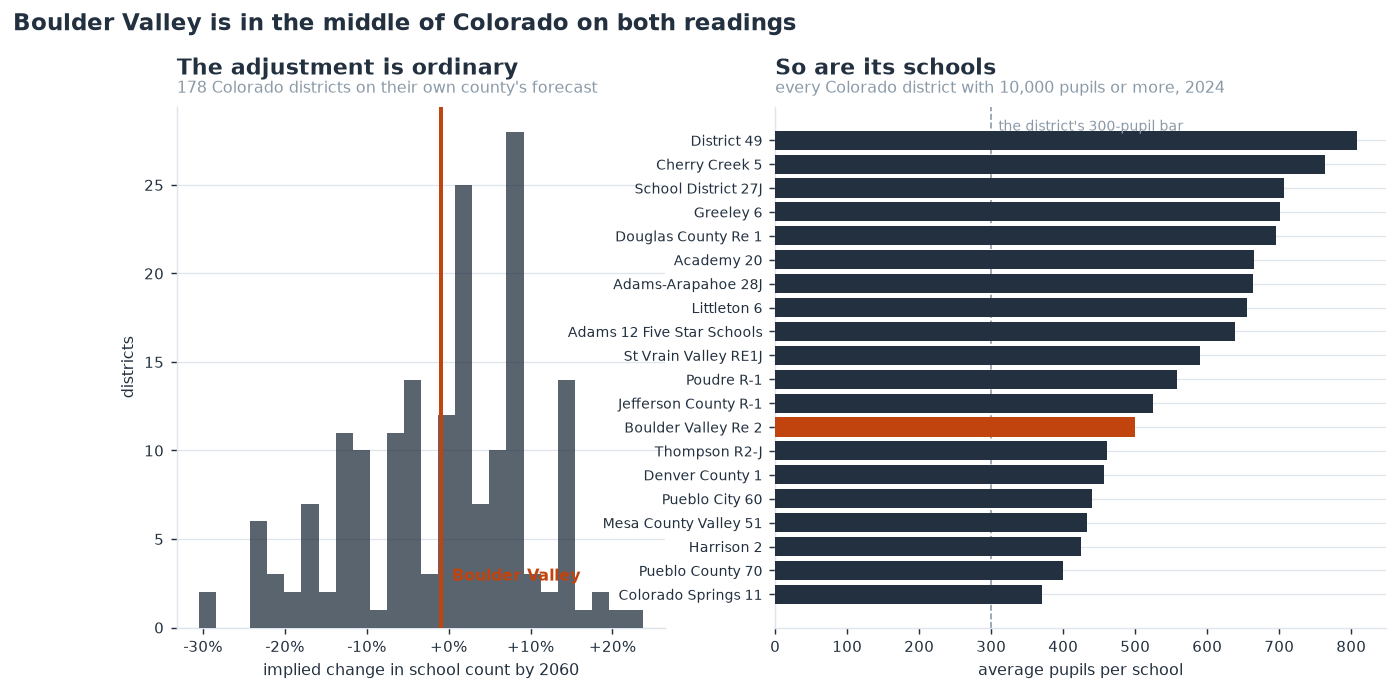

In [36]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12.0, 5.2),
                                  gridspec_kw={"width_ratios": [1, 1.25]})

left.hist(steady["schools_change"] * 100, bins=26, color=INK, alpha=0.75, zorder=3)
left.axvline(bvsd_row["schools_change"] * 100, color=ACCENT, lw=2.2, zorder=4)
left.annotate("Boulder Valley", (bvsd_row["schools_change"] * 100, 0),
              xytext=(6, 26), textcoords="offset points", fontsize=9,
              color=ACCENT, fontweight="bold")
left.xaxis.set_major_formatter(lambda v, _: f"{v:+.0f}%")
left.set_xlabel(f"implied change in school count by {HORIZON}")
left.set_ylabel("districts")
finish(left, "The adjustment is ordinary",
       f"{len(steady)} Colorado districts on their own county's forecast")

order = peers.sort_values("average_school")
colours = [ACCENT if code == BVSD_CODE else INK for code in order["district_code"]]
right.barh(range(len(order)), order["average_school"], color=colours, zorder=3)
right.set_yticks(range(len(order)))
right.set_yticklabels(order["district_name"], fontsize=8)
right.axvline(BVSD_BAR_TOTAL, color=MUTED, lw=0.9, ls="--")
right.annotate(f"the district's {BVSD_BAR_TOTAL:.0f}-pupil bar",
               (BVSD_BAR_TOTAL, len(order) - 0.6), xytext=(4, 0),
               textcoords="offset points", fontsize=8, color=MUTED)
right.set_xlabel("average pupils per school")
finish(right, "So are its schools",
       f"every Colorado district with {PEER_FLOOR:,} pupils or more, {BASE_YEAR}")
fig.suptitle("Boulder Valley is in the middle of Colorado on both readings",
             fontsize=13, fontweight="bold", x=0.02, ha="left", y=1.02)
fig.savefig(OUTPUT / "alt-fig8-statewide.png", bbox_inches="tight")
plt.show()

### What that settles, and what it does not

**Boulder Valley is not an outlier in either direction.** The adjustment its
demography implies is near the middle of Colorado's, and its schools are a
little smaller than its peers' without being unusual: several large
districts, Denver and Colorado Springs among them, run smaller ones.

That cuts against two things the proposal leans on. It is not true that
Boulder Valley faces a decline out of proportion to the rest of the state,
and it is not true that a district of its size cannot operate schools of the
size it has — most of the difference between it and its peers is a hundred
pupils a school, and Colorado Springs 11 runs fifty-nine schools averaging
377.

What it does not settle is whether *this* district should run schools of
that size. A peer median is a description of what districts do, not an
argument that they are right to. The bar in section 3 is BVSD's own, and it
is the one the levers are scored against.

## 7. What happened after

Section 1 asked what predicts a closure. It did not ask what a closure does,
and the proposal's case rests on an answer to that: close buildings now and
the district comes out the other side in better shape.

The archive can test it. Thirty-three Colorado districts have run fifty-nine
closure rounds since 1992 — not a single closure, which happens constantly,
but two or more schools at once amounting to between a twentieth and a half
of the district.
**Boulder Valley's own 2004 round, five schools of fifty-eight, is one of
them.** What happened to those districts afterwards is a question with an
answer.

In [37]:
end_year = int(school_panel["year"].max())
closed_schools = (school_panel.dropna(subset=["ncessch"])
                  .loc[lambda f: f["ncessch"].isin(shut)]
                  .groupby("ncessch")
                  .agg(last_year=("year", "max"),
                       district=("district_code", "last")).reset_index())
closed_schools = closed_schools[closed_schools["last_year"] < end_year]
rounds = (closed_schools.groupby(["district", "last_year"]).size()
          .rename("closed").reset_index())
# A school last seen in year t is gone from t+1, so that is the round's year.
rounds["event_year"] = rounds["last_year"] + 1
school_count = panel.set_index(["district_code", "year"])["schools"]
rounds["schools_before"] = [school_count.get((d, y), np.nan)
                            for d, y in zip(rounds["district"], rounds["last_year"])]
rounds["share_closed"] = rounds["closed"] / rounds["schools_before"]
# Two or more schools and at least a twentieth of the district. The upper
# bound removes the handful of district-years where every school changes code
# at once, which is a reorganisation in the records rather than a closure.
ROUND_MIN, SHARE_MIN, SHARE_MAX = 2, 0.05, 0.5
closure_rounds = rounds[(rounds["closed"] >= ROUND_MIN)
                        & rounds["share_closed"].between(SHARE_MIN, SHARE_MAX)]
first_round = (closure_rounds.sort_values("event_year")
               .groupby("district", as_index=False).first())
print(f"{len(closure_rounds)} closure rounds in "
      f"{closure_rounds['district'].nunique()} districts, "
      f"{closure_rounds['event_year'].min()}-{closure_rounds['event_year'].max()}")
print(f"the study uses each district's first round: {len(first_round)} events")
names = panel.drop_duplicates("district_code").set_index("district_code")["district_name"]
print("\nthe ten largest rounds:")
print(closure_rounds.nlargest(10, "closed")
      .assign(district_name=lambda d: d["district"].map(names))
      [["district_name", "event_year", "closed", "schools_before", "share_closed"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
closure_rounds.to_csv(OUTPUT / "alt-closure-rounds.csv", index=False)

59 closure rounds in 33 districts, 1992-2024
the study uses each district's first round: 33 events

the ten largest rounds:
          district_name  event_year  closed  schools_before  share_closed
   JEFFERSON COUNTY R-1        2024      16          146.00          0.11
        DENVER COUNTY 1        2009      10          153.00          0.07
    COLORADO SPRINGS 11        2010       9           68.00          0.13
             MAPLETON 1        2007       6           18.00          0.33
    BOULDER VALLEY RE 2        2004       5           58.00          0.09
    COLORADO SPRINGS 11        2006       5           67.00          0.07
GUNNISON WATERSHED RE1J        1998       5           11.00          0.45
             POUDRE R-1        2004       5           55.00          0.09
              GREELEY 6        2011       5           28.00          0.18
         CHERRY CREEK 5        2004       4           54.00          0.07


### The event study

District and year fixed effects, with the year before the round left out, so
each coefficient reads as the difference from that year against districts
that were not closing schools then. Standard errors are clustered on the
district. Five years either side, with anything beyond folded into the end
points.

**What to watch for is the run-up.** Section 1 established that closures
follow falling enrollment, so the years before a round should already show
it. The question is what the years after do.

In [38]:
study = panel.dropna(subset=["enrollment", "teacher_fte", "schools"]).copy()
study = study[(study["enrollment"] > 0) & (study["teacher_fte"] > 0)
              & (study["schools"] > 0)]
study = study.merge(first_round[["district", "event_year"]],
                    left_on="district_code", right_on="district", how="left")
LEAD, LAG = -4, 5
study["k"] = (study["year"] - study["event_year"]).clip(LEAD, LAG)
windows = [k for k in range(LEAD, LAG + 1) if k != -1]
terms = []
for k in windows:
    name = f"k_{'before' if k < 0 else 'after'}{abs(k)}"
    # Districts that never ran a round are zero throughout: they are the
    # comparison, and they enter through the year effects.
    study[name] = (study["event_year"].notna() & (study["k"] == k)).astype(int)
    terms.append(name)
print(f"{len(study):,} district-years: "
      f"{int(study['event_year'].notna().sum()):,} in districts that ran a round, "
      f"{int(study['event_year'].isna().sum()):,} in districts that did not")

paths = []
for label, column in [("enrolment", "enrollment"), ("staff", "teacher_fte"),
                      ("schools", "schools")]:
    study[f"log_{column}"] = np.log(study[column])
    fit = smf.ols(f"log_{column} ~ {' + '.join(terms)} + C(district_code) + C(year)",
                  data=study).fit(cov_type="cluster",
                                  cov_kwds={"groups": study["district_code"]})
    assert np.linalg.matrix_rank(fit.model.exog) == fit.model.exog.shape[1], \
        f"{label}: the design matrix is rank-deficient"
    for k, term in zip(windows, terms):
        low, high = fit.conf_int().loc[term]
        paths.append({"outcome": label, "k": k,
                      "effect": np.exp(fit.params[term]) - 1,
                      "low": np.exp(low) - 1, "high": np.exp(high) - 1,
                      "significant": bool(low * high > 0)})
    paths.append({"outcome": label, "k": -1, "effect": 0.0, "low": 0.0,
                  "high": 0.0, "significant": False})
paths = pd.DataFrame(paths).sort_values(["outcome", "k"])
paths.to_csv(OUTPUT / "alt-closure-impacts.csv", index=False)
for label in ("schools", "enrolment", "staff"):
    one = paths[paths["outcome"] == label].set_index("k")
    print(f"\n{label}:")
    for k in range(LEAD, LAG + 1):
        row = one.loc[k]
        mark = " *" if row["significant"] else ""
        print(f"  {k:+d}: {row['effect']:+6.1%} "
              f"[{row['low']:+6.1%}, {row['high']:+6.1%}]{mark}")

5,272 district-years: 986 in districts that ran a round, 4,286 in districts that did not



schools:
  -4: -10.6% [-17.9%,  -2.6%] *
  -3:  -6.4% [-13.4%,  +1.2%]
  -2:  -4.3% [ -9.5%,  +1.3%]
  -1:  +0.0% [ +0.0%,  +0.0%]
  +0: -17.5% [-23.4%, -11.1%] *
  +1: -15.6% [-22.5%,  -8.1%] *
  +2: -13.2% [-20.9%,  -4.7%] *
  +3: -14.7% [-22.5%,  -6.0%] *
  +4: -15.3% [-23.5%,  -6.2%] *
  +5: -10.5% [-21.4%,  +1.9%]

enrolment:
  -4:  +5.5% [ -3.9%, +15.9%]
  -3:  +3.7% [ -4.4%, +12.5%]
  -2:  +1.4% [ -4.4%,  +7.5%]
  -1:  +0.0% [ +0.0%,  +0.0%]
  +0:  -2.2% [ -5.0%,  +0.8%]
  +1:  -1.7% [ -5.3%,  +2.1%]
  +2:  -1.8% [ -6.0%,  +2.6%]
  +3:  -2.3% [ -7.5%,  +3.2%]
  +4:  -0.1% [ -5.7%,  +5.9%]
  +5:  +2.5% [ -7.2%, +13.2%]

staff:
  -4:  +4.5% [ -4.3%, +14.2%]
  -3:  +1.0% [ -3.8%,  +6.2%]
  -2:  +1.3% [ -0.9%,  +3.5%]
  -1:  +0.0% [ +0.0%,  +0.0%]
  +0:  +1.3% [ -0.6%,  +3.2%]
  +1:  +0.1% [ -2.7%,  +3.0%]
  +2:  +0.1% [ -3.5%,  +3.8%]
  +3:  -0.1% [ -4.7%,  +4.7%]
  +4:  +2.1% [ -3.2%,  +7.8%]
  +5:  +5.7% [ -4.0%, +16.5%]


### Closing schools removes schools

And, within what this can measure, nothing else.

**The school count falls about 17% at the round** and is still 15% down four
years later. By the fifth year the estimate has drifted to 10% and its
interval covers zero — but hold that thought, because section 8 shows the
drift is an artifact of how this regression picks its comparisons, not
something the districts did.

**Enrolment does not move.** No horizon differs from the year before the
round, and the intervals are tight enough to rule out a fall of more than
about five per cent in the years just after it. Districts that closed
schools did not then lose pupils faster than districts that did not.

**Staffing does not move either.** If anything the point estimates drift up.
The children still have to be taught, and they are taught by roughly the
same number of people in fewer buildings.

One thing here is a warning rather than a result: four years before a round
the school count is already 11% down, and that interval excludes zero. A
design whose pre-period is not flat is a design to be careful with, which is
the second reason for section 8.

That is the finding, and it is worth stating in the proposal's own terms:
**a closure round changes the number of buildings, not the number of pupils
or the number of teachers.** Whatever case there is for closing schools is a
case about buildings. It is not a case about demography, and on this evidence
it is not a case about staff.

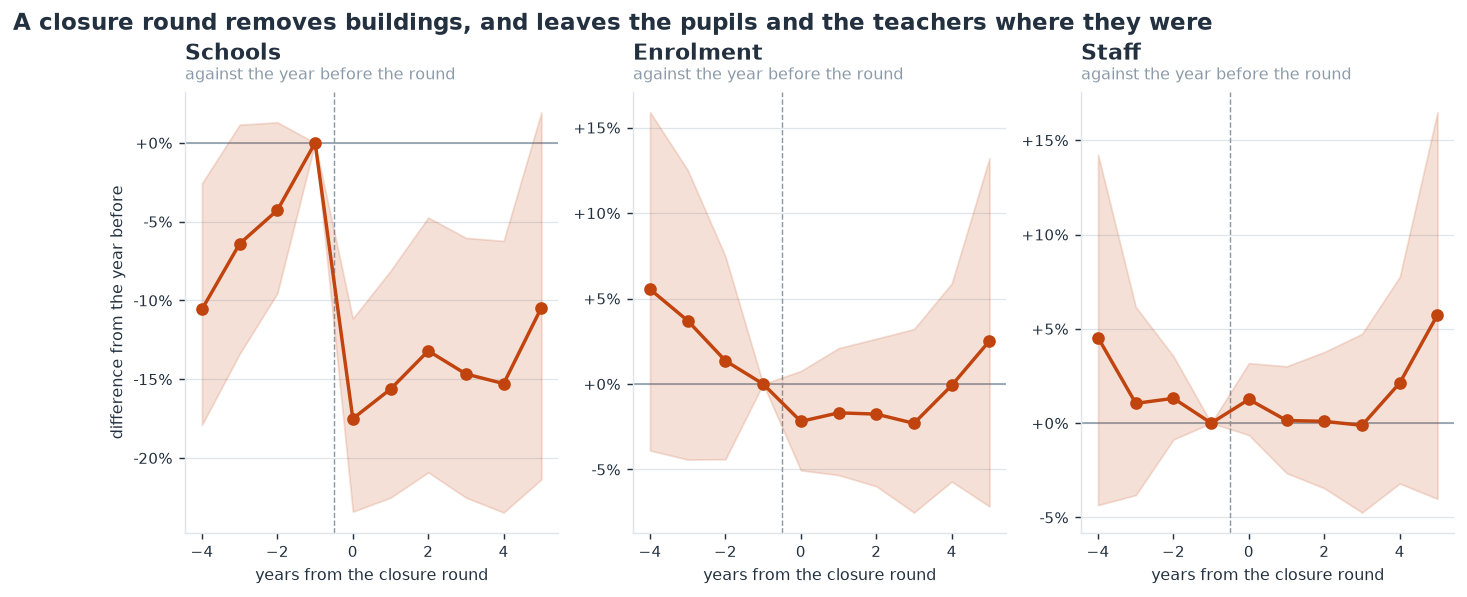

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.4), sharex=True)
for ax, label in zip(axes, ("schools", "enrolment", "staff")):
    one = paths[paths["outcome"] == label].sort_values("k")
    ax.axhline(0, color=MUTED, lw=0.9)
    ax.axvline(-0.5, color=MUTED, lw=0.8, ls="--")
    ax.fill_between(one["k"], one["low"] * 100, one["high"] * 100,
                    color=ACCENT, alpha=0.16, zorder=2)
    ax.plot(one["k"], one["effect"] * 100, marker="o", color=ACCENT, lw=1.9,
            zorder=3)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0f}%")
    ax.set_xlabel("years from the closure round")
    finish(ax, label.capitalize(), "against the year before the round")
axes[0].set_ylabel("difference from the year before")
fig.suptitle("A closure round removes buildings, and leaves the pupils and the "
             "teachers where they were", fontsize=13, fontweight="bold",
             x=0.02, ha="left", y=1.02)
fig.savefig(OUTPUT / "alt-fig9-closure-impacts.png", bbox_inches="tight")
plt.show()

### Boulder Valley's own round

The district closed five of its fifty-eight schools in 2004. It is the
nearest thing to a control for this proposal that exists, and it is in the
archive.

In [40]:
own = (panel[(panel["district_code"] == BVSD_CODE)
             & panel["year"].between(1999, 2014)]
       [["year", "enrollment", "teacher_fte", "schools", "pop_5_17"]]
       .sort_values("year"))
print(own.to_string(index=False, float_format=lambda v: f"{v:,.0f}"))
print("\nCDE publishes no district enrollment for 2000 to 2003, so the years "
      "either side of\nthe round are 1999 and 2004.")
after = own[own["year"] == 2012].iloc[0]
at_round = own[own["year"] == 2004].iloc[0]
print(f"\nSchools: 58 before the round, {at_round['schools']:.0f} after it, "
      f"{after['schools']:.0f} by 2012.")
print(f"Enrolment: {at_round['enrollment']:,.0f} in 2004, "
      f"{after['enrollment']:,.0f} in 2012 "
      f"({after['enrollment'] / at_round['enrollment'] - 1:+.1%}).")
print(f"Staff: {at_round['teacher_fte']:,.0f} in 2004, "
      f"{after['teacher_fte']:,.0f} in 2012 "
      f"({after['teacher_fte'] / at_round['teacher_fte'] - 1:+.1%}).")
own.to_csv(OUTPUT / "alt-bvsd-2004-round.csv", index=False)

 year  enrollment  teacher_fte  schools  pop_5_17
 1999      26,974          NaN       57    47,852
 2000         NaN        1,548       60    45,400
 2001      24,803        1,653       58    46,840
 2002      24,755        1,670       58    46,661
 2003      27,804        1,585       58    45,891
 2004      27,926        1,656       53    45,409
 2005      27,933        1,654       53    44,843
 2006      28,171        1,700       54    45,246
 2007      28,543        1,717       54    45,553
 2008      28,743        1,730       54    45,954
 2009      28,938        1,708       54    46,149
 2010      29,526        1,688       55    46,415
 2011      29,780        1,704       55    47,258
 2012      30,041        1,703       56    48,157
 2013      30,546        1,679       57    49,022
 2014      30,908        1,668       57    49,229

CDE publishes no district enrollment for 2000 to 2003, so the years either side of
the round are 1999 and 2004.

Schools: 58 before the round, 53 aft

### The last round was not a permanent contraction

Boulder Valley closed five schools in 2004, and by 2012 was **back to
fifty-six schools with two thousand more pupils** than it had at the round —
fifty-seven by 2013, which is where it had been in 1999. Its county's 5-to-17
population had turned up again, and the district followed it.

That is not an argument that this round will end the same way — the SDO's
forecast says Boulder County's children do not come back this time, which is
the whole basis of section 2. It is an argument about what a closure round
settles, which is less than the proposal implies. The district has been here
before, closed schools, and then needed them.

### What this cannot tell you

The comparison districts are those not running a round in the same year, and
rounds happen in different years, so a district treated early sits in the
comparison group for one treated later. Where the effect of a round differs
across districts that arrangement can bias the average. **Section 8 removes
it and asks the question again.** The window is five years; a closure could
still cost a district pupils over twenty. And an interval that rules out a
fall of more than five per cent does not rule out a fall of four.

## 8. Asking it again without the bad comparisons

Section 7's regression compares a district that closed schools with every
district that did not close schools *that year*. Some of those comparison
districts had closed schools four years earlier and were still living with
the result. Comparing a district at its round against a district in its
own aftermath is not a clean comparison, and with rounds spread from 1992
to 2019 the regression makes a great many of them.

It matters because the two-way fixed-effects estimate is a weighted average
of every such comparison, and some of the weights are negative. A finding
can then come out of the weighting rather than out of the districts.

The fix is to build only the comparisons that are clean. For each cohort of
districts that ran a round in the same year, take the change from the year
before the round to the year in question, and subtract the same change in
districts that had not yet run one. Every comparison is then a district at
its round against a district that has not had one. The cohort effects are
averaged with the number of districts as weights, which is the
Callaway-Sant'Anna estimator. The intervals come from resampling the
districts, because a district's years are not independent of each other.

In [41]:
def att_gt(wide, event_year, lo=-4, hi=5):
    """ATT(g, t): every cohort against districts not yet treated at t.

    `wide` is districts down and years across; `event_year` is the round's
    year, or NaN for a district that never ran one.
    """
    years = list(wide.columns)
    ev = event_year.reindex(wide.index).to_numpy(dtype=float)
    never = np.isnan(ev)
    rows = []
    for g in sorted({int(v) for v in ev[~never]}):
        base = g - 1                       # the last year before the round
        if base not in wide.columns:
            continue
        members = ev == g
        col_base = wide[base].to_numpy()
        for t in years:
            if t == base or t < years[0] + 1 or not lo <= t - g <= hi:
                continue
            delta = wide[t].to_numpy() - col_base
            present = ~np.isnan(delta)
            # Not yet treated at whichever of t and g is later, so a district
            # already living with its own round is never a comparison.
            controls = (never | (ev > max(t, g))) & ~members
            treated, control = members & present, controls & present
            # A cohort of one district is still a clean 2x2 - its effect is
            # that district's change less the comparisons'. Requiring two
            # would throw out 29 of the 33 districts and rest the pre-trend
            # on three of them. The uncertainty comes from the bootstrap.
            if treated.sum() < 1 or control.sum() < 5:
                continue
            rows.append((g, t, t - g, delta[treated].mean() - delta[control].mean(),
                         treated.sum()))
    return np.array(rows, dtype=float) if rows else np.empty((0, 5))


def by_event_time(table):
    """Average the cohort effects at each event time, weighted by cohort size."""
    if len(table) == 0:
        return {}
    return {int(e): float(np.average(rows[:, 3], weights=rows[:, 4]))
            for e in np.unique(table[:, 2])
            for rows in [table[table[:, 2] == e]]}


BOOT_REPS, BOOT_SEED = 1000, 20260918
cs_paths, cs_counts = [], None
for label, column in [("schools", "schools"), ("enrolment", "enrollment"),
                      ("staff", "teacher_fte")]:
    wide = study.pivot_table(index="district_code", columns="year",
                             values=f"log_{column}")
    events = study.groupby("district_code")["event_year"].first().reindex(wide.index)
    table = att_gt(wide, events)
    point = by_event_time(table)
    if cs_counts is None:
        cs_counts = {int(e): int(table[table[:, 2] == e][:, 4].sum())
                     for e in np.unique(table[:, 2])}

    # Resample whole districts, not district-years: a district's years move
    # together, and treating them as independent would understate the spread.
    rng = np.random.default_rng(BOOT_SEED)
    values, event_values = wide.to_numpy(), events.to_numpy(dtype=float)
    n, draws = len(wide), []
    for _ in range(BOOT_REPS):
        pick = rng.integers(0, n, n)
        names = [f"b{i}" for i in range(n)]
        drawn = by_event_time(att_gt(
            pd.DataFrame(values[pick], columns=wide.columns, index=names),
            pd.Series(event_values[pick], index=names)))
        if drawn:
            draws.append(drawn)
    spread = pd.DataFrame(draws)
    for k in sorted(point):
        low, high = spread[k].quantile(0.025), spread[k].quantile(0.975)
        cs_paths.append({"outcome": label, "k": k,
                         "effect": np.exp(point[k]) - 1,
                         "low": np.exp(low) - 1, "high": np.exp(high) - 1,
                         "significant": bool(low * high > 0),
                         "reps": len(spread)})
cs_paths = pd.DataFrame(cs_paths).sort_values(["outcome", "k"])
cs_paths.to_csv(OUTPUT / "alt-closure-impacts-staggered.csv", index=False)

never_ran = study.loc[study["event_year"].isna(), "district_code"].nunique()
print(f"{study.loc[study['event_year'].notna(), 'event_year'].nunique()} cohorts "
      f"covering {len(first_round)} districts, against {never_ran} that never "
      f"ran a round\n{BOOT_REPS} bootstrap draws, resampled on the district\n")
for label in ("schools", "enrolment", "staff"):
    one = cs_paths[cs_paths["outcome"] == label].set_index("k")
    print(f"{label}:")
    for k in sorted(one.index):
        row = one.loc[k]
        print(f"  {k:+d}: {row['effect']:+6.1%} "
              f"[{row['low']:+6.1%}, {row['high']:+6.1%}]"
              f"{' *' if row['significant'] else ''}"
              f"   {cs_counts.get(k, 0)} districts")
    print()

18 cohorts covering 33 districts, against 145 that never ran a round
1000 bootstrap draws, resampled on the district

schools:
  -4:  -8.4% [-21.2%,  +3.0%]   13 districts
  -3:  -4.7% [-11.8%,  +1.3%]   23 districts
  -2:  -4.0% [ -9.7%,  +1.2%]   30 districts
  +0: -17.3% [-23.4%, -11.3%] *   30 districts
  +1: -14.9% [-22.3%,  -7.8%] *   28 districts
  +2: -12.1% [-20.5%,  -4.2%] *   29 districts
  +3: -14.6% [-22.3%,  -6.2%] *   29 districts
  +4: -15.1% [-23.3%,  -6.3%] *   28 districts
  +5: -16.3% [-25.1%,  -6.6%] *   27 districts

enrolment:
  -4:  +7.7% [ -1.2%, +19.1%]   13 districts
  -3:  +4.2% [ -4.1%, +12.3%]   23 districts
  -2:  +2.1% [ -4.1%,  +8.5%]   30 districts
  +0:  -2.1% [ -5.1%,  +0.5%]   30 districts
  +1:  -2.3% [ -6.0%,  +1.2%]   28 districts
  +2:  -2.3% [ -6.7%,  +2.1%]   29 districts
  +3:  -0.7% [ -5.8%,  +4.7%]   29 districts
  +4:  +1.0% [ -4.8%,  +7.4%]   28 districts
  +5:  -0.2% [ -6.4%,  +6.7%]   27 districts

staff:
  -4:  +5.3% [ +0.1%, +10.8%] *

### The finding holds, and the closures hold longer than section 7 said

**Schools fall and stay fallen.** Down 17.3% at the round, against section
7's 17.5% — the same answer. The difference is what happens next: section 7
has the effect fading to 10.5% by the fifth year with its interval covering
zero, while on clean comparisons it is still 16.3% down, and every year
after the round excludes zero. The fade was the
bad comparisons. A district five years past its own round was being used as
a yardstick for a district at its round, which makes the gap between them
close over time whether or not anything reopened. It did not reopen.

The three years before the round are flat, all three intervals covering
zero, which is what a design like this has to show before its after-years
mean anything.

**Enrolment still does not move.** Nothing after the round differs from the
year before it, at any horizon; five years out the estimate is two tenths of
one per cent, with the interval running from -6.4% to +6.7%. Districts that
closed schools did not go on to lose pupils faster than districts that did
not.

**Staffing still does not move after the round** — and section 7's hint that
it drifts upward, to +5.7% by the fifth year, does not survive either. It
comes out at +2.2%, well inside its interval.

And the pre-period straightens out. Section 7's school count was already 11%
down four years before a round, with the interval excluding zero; on clean
comparisons it is 8% down and the interval covers zero. That too was the
comparison group, not the districts.

One crack is worth naming rather than hiding. Four years *before* a round,
staffing sits about 5% high and that interval only just excludes zero.
Districts drift into closure rounds carrying more staff than their
comparisons. The two nearer pre-years are flat and nothing after the round
moves, but the enrolment null is the sturdier of the two.

So the answer to section 7's own caveat is that fixing it did not change the
finding, only strengthened the part about buildings. **A closure round
changes the number of buildings, durably. It does not change the number of
pupils, and it does not change the number of teachers.**

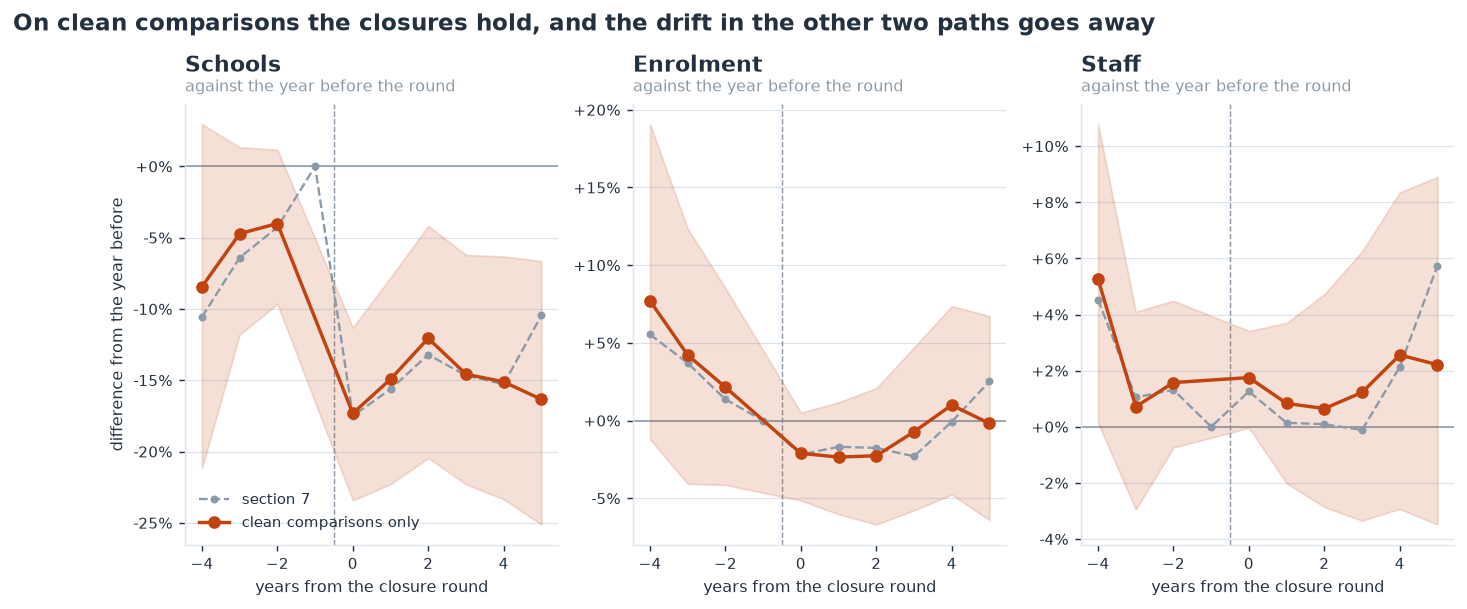

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.4), sharex=True)
for ax, label in zip(axes, ("schools", "enrolment", "staff")):
    twfe = paths[paths["outcome"] == label].sort_values("k")
    one = cs_paths[cs_paths["outcome"] == label].sort_values("k")
    ax.axhline(0, color=MUTED, lw=0.9)
    ax.axvline(-0.5, color=MUTED, lw=0.8, ls="--")
    ax.fill_between(one["k"], one["low"] * 100, one["high"] * 100,
                    color=ACCENT, alpha=0.16, zorder=2)
    ax.plot(twfe["k"], twfe["effect"] * 100, marker="o", ms=3.4, color=MUTED,
            lw=1.3, ls="--", zorder=3, label="section 7")
    ax.plot(one["k"], one["effect"] * 100, marker="o", color=ACCENT, lw=1.9,
            zorder=4, label="clean comparisons only")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0f}%")
    ax.set_xlabel("years from the closure round")
    finish(ax, label.capitalize(), "against the year before the round")
axes[0].set_ylabel("difference from the year before")
axes[0].legend(frameon=False, fontsize=8.5, loc="lower left")
fig.suptitle("On clean comparisons the closures hold, and the drift in the "
             "other two paths goes away", fontsize=13, fontweight="bold",
             x=0.02, ha="left", y=1.04)
fig.savefig(OUTPUT / "alt-fig10-closure-impacts-staggered.png",
            bbox_inches="tight")
plt.show()

## 9. Where the children went, 2000 to 2020

Every count of children so far has been 2020, which can say where they are
and not whether they moved. The 2000 census counted the same ground, and
section 5 of the retrieval notebook put both years on 2000 tract geometry so
the comparison is of places rather than of tract numbers.

This is the question the proposal's framing answers without asking:
**children left, so schools must close.** The first half of that is testable.

In [43]:
import geopandas as gpd

then_now = gpd.read_file(ANALYSIS / "bvsd-tracts-2000-2020.geojson")
grew = then_now[then_now["change"] > 0]
fell = then_now[then_now["change"] < 0]
print(f"{len(then_now)} tracts, covering the district")
print(f"aged 5 to 17: {then_now['children_2000'].sum():,.0f} in 2000, "
      f"{then_now['children_2020'].sum():,.0f} in 2020 "
      f"({then_now['children_2020'].sum() / then_now['children_2000'].sum() - 1:+.1%})")
print(f"\n{len(grew)} tracts gained children, {len(fell)} lost them")
print(f"  the gainers gained {grew['change'].sum():,.0f} between them")
print(f"  the losers lost    {fell['change'].sum():,.0f}")
print(f"\nbiggest falls:")
print(fell.nsmallest(6, "change")[["tract2000", "children_2000", "children_2020",
                                   "change", "pct_change"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print(f"\nbiggest rises:")
print(grew.nlargest(6, "change")[["tract2000", "children_2000", "children_2020",
                                  "change", "pct_change"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
then_now.drop(columns="geometry").to_csv(OUTPUT / "alt-tract-change.csv", index=False)

45 tracts, covering the district
aged 5 to 17: 28,409 in 2000, 28,780 in 2020 (+1.3%)

19 tracts gained children, 26 lost them
  the gainers gained 3,612 between them
  the losers lost    -3,241

biggest falls:
  tract2000  children_2000  children_2020  change  pct_change
08013013111            775         474.00 -301.00       -0.39
08013013006           1319       1,079.00 -240.00       -0.18
08013013702            856         621.00 -235.00       -0.27
08013013004            985         763.00 -222.00       -0.23
08013012106            735         532.00 -203.00       -0.28
08013012710            783         581.00 -202.00       -0.26

biggest rises:
  tract2000  children_2000  children_2020  change  pct_change
08013013106           1874       2,849.00  975.00        0.52
08013013003            919       1,374.00  455.00        0.50
08013012105            757       1,204.00  447.00        0.59
08013012908           1258       1,596.00  338.00        0.27
08013012906            663   

### The children did not leave. They moved.

**Boulder Valley has as many school-age children as it had in 2000** — 1.3%
more, which on 28,000 children is noise, not growth. Over the same twenty
years the district's enrollment fell.

So the two facts the proposal runs together are separate. The district is
losing pupils. The ground it sits on is not losing children. Whatever is
emptying the schools is happening between the child and the school, not
before it: the county's *forecast* falls, and section 2 takes that
seriously, but the fall has not happened yet and the last twenty years were
not it.

**Within the district the movement is large and it cancels.** Nineteen of
forty-five tracts gained children and twenty-six lost them, and the two
sides very nearly balance. That is the finding a district-wide total hides
and a closure map cannot afford to miss: the schools that are short of
children are not short because the district ran out, but because the
children are in a different tract from the building.

That is an argument for the lever that moves lines, and against the one that
removes buildings — a building removed cannot be filled again by children
arriving two tracts away, and section 8 showed that closures do not reverse.

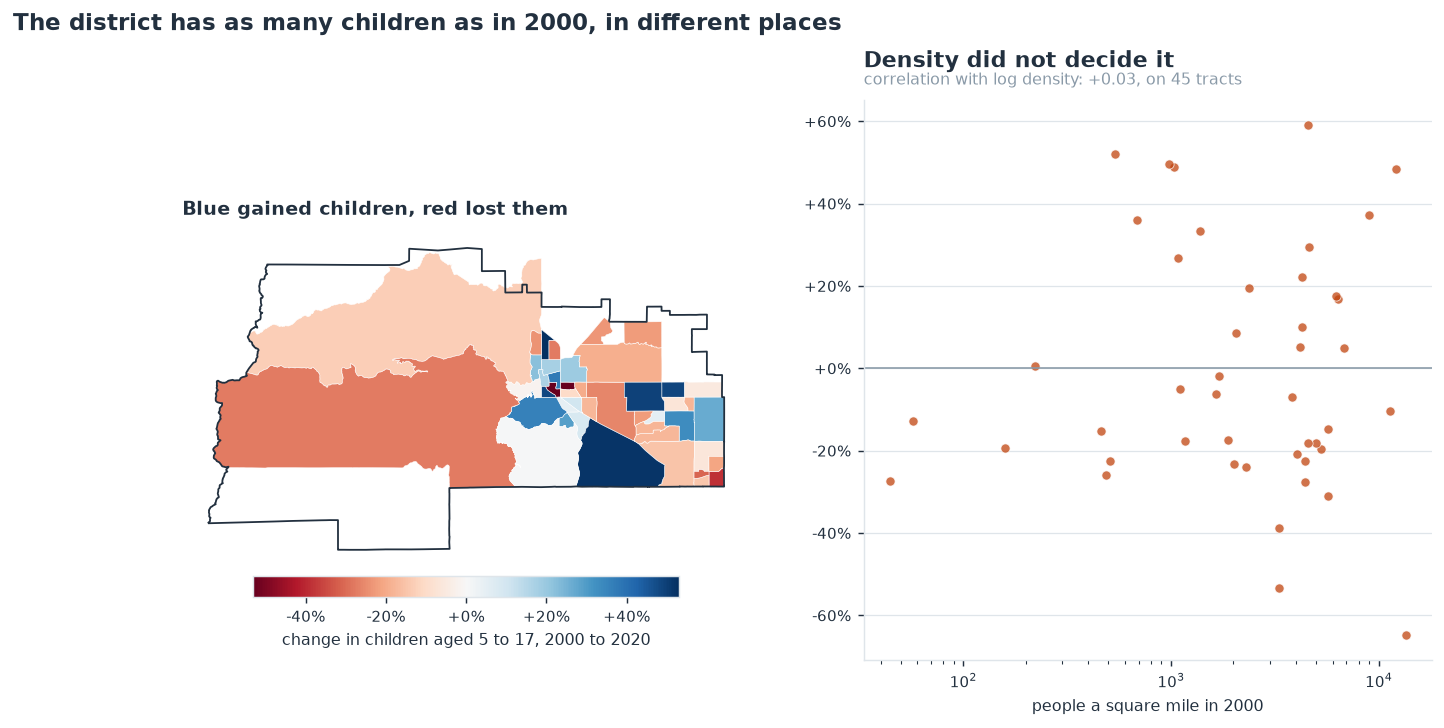

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.6))
boundary = gpd.read_file(ANALYSIS / "bvsd-boundary.geojson")
limit = float(np.nanpercentile(np.abs(then_now["pct_change"]), 95))
then_now.plot(column="pct_change", cmap="RdBu", vmin=-limit, vmax=limit,
              linewidth=0.3, edgecolor="white", ax=axes[0], legend=True,
              legend_kwds={"label": "change in children aged 5 to 17, 2000 to 2020",
                           "orientation": "horizontal", "shrink": 0.75,
                           "format": lambda v, _: f"{v:+.0%}", "pad": 0.02})
boundary.boundary.plot(ax=axes[0], color=INK, linewidth=1.0)
axes[0].set_axis_off()
axes[0].set_title("Blue gained children, red lost them", fontsize=10.5,
                  loc="left", color=INK)

ax = axes[1]
ax.axhline(0, color=MUTED, lw=0.9)
density_2000 = then_now["population_2000"] / then_now["land_sq_mi"]
ax.scatter(density_2000, then_now["pct_change"] * 100, s=26, color=ACCENT,
           alpha=0.75, edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_xlabel("people a square mile in 2000")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0f}%")
usable = then_now[density_2000.gt(0) & then_now["pct_change"].notna()]
rho = np.log10(density_2000[usable.index]).corr(usable["pct_change"])
finish(ax, "Density did not decide it",
       f"correlation with log density: {rho:+.2f}, on {len(usable)} tracts")
fig.suptitle("The district has as many children as in 2000, in different "
             "places", fontsize=13, fontweight="bold", x=0.02, ha="left", y=1.0)
fig.savefig(OUTPUT / "alt-fig11-tract-change.png", bbox_inches="tight")
plt.show()

### And across the Front Range

Density is offered as the explanation — dense places have fewer children, so
a city that densifies loses its schools. Every tract in the nine Front Range
counties can be asked at once.

In [45]:
front_range = pd.read_csv(ANALYSIS / "frontrange-tracts-2020.csv",
                          dtype={"GEOID": str, "COUNTYFP": str})
usable = front_range[front_range["people_per_sq_mi"].gt(0)
                     & front_range["child_share"].notna()
                     & front_range["population"].gt(200)].copy()
rho_all = usable["log_density"].corr(usable["child_share"], method="spearman")
print(f"{len(usable):,} tracts with more than 200 residents")
print(f"rank correlation between density and the share of residents under 18: "
      f"{rho_all:+.3f}\n")
bands = pd.cut(usable["people_per_sq_mi"],
               [0, 100, 1_000, 3_000, 6_000, 10_000, np.inf],
               labels=["under 100", "100-1k", "1k-3k", "3k-6k", "6k-10k", "over 10k"])
print(usable.groupby(bands, observed=True)
      .agg(tracts=("GEOID", "size"), population=("population", "sum"),
           children=("children_under_18", "sum"))
      .assign(child_share=lambda f: f["children"] / f["population"])
      .to_string(float_format=lambda v: f"{v:,.3f}"))
print("\nby county, tracts above 3,000 a square mile against the rest:")
dense = usable["people_per_sq_mi"] > 3_000
print(usable.groupby(["county", dense.map({True: "dense", False: "not dense"})],
                     observed=True)
      .apply(lambda f: f["children_under_18"].sum() / f["population"].sum(),
             include_groups=False)
      .unstack().to_string(float_format=lambda v: f"{v:.3f}"))

1,091 tracts with more than 200 residents
rank correlation between density and the share of residents under 18: -0.116

                  tracts  population  children  child_share
people_per_sq_mi                                           
under 100             58      181187     40251        0.222
100-1k               141      610358    149271        0.245
1k-3k                199      880441    202452        0.230
3k-6k                399     1710209    379948        0.222
6k-10k               214      954762    213675        0.224
over 10k              80      317129     48192        0.152

by county, tracts above 3,000 a square mile against the rest:
people_per_sq_mi  dense  not dense
county                            
Adams             0.251      0.271
Arapahoe          0.231      0.247
Boulder           0.175      0.203
Broomfield        0.235      0.195
Denver            0.185      0.235
Douglas           0.268      0.248
El Paso           0.235      0.235
Jefferson         0.19

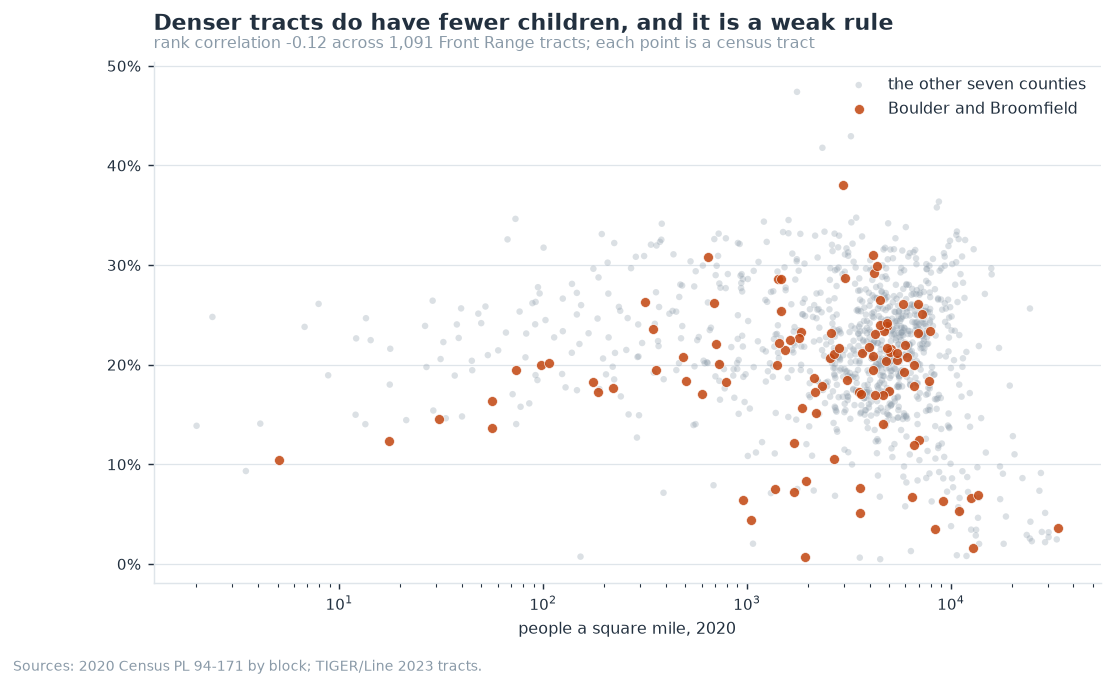

In [46]:
fig, ax = plt.subplots(figsize=(9.4, 5.2))
for county, group in usable.groupby("county"):
    mark = county in ("Boulder", "Broomfield")
    ax.scatter(group["people_per_sq_mi"], group["child_share"] * 100,
               s=30 if mark else 13, alpha=0.85 if mark else 0.3,
               color=ACCENT if mark else MUTED, zorder=3 if mark else 2,
               edgecolor="white" if mark else "none", linewidth=0.4,
               label="Boulder and Broomfield" if mark and county == "Boulder" else
                     ("the other seven counties" if county == "Adams" else None))
ax.set_xscale("log")
ax.set_xlabel("people a square mile, 2020")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.legend(frameon=False, fontsize=9, loc="upper right")
finish(ax, "Denser tracts do have fewer children, and it is a weak rule",
       f"rank correlation {rho_all:+.2f} across {len(usable):,} Front Range tracts; "
       "each point is a census tract",
       "Sources: 2020 Census PL 94-171 by block; TIGER/Line 2023 tracts.")
fig.savefig(OUTPUT / "alt-fig12-density-children.png", bbox_inches="tight")
plt.show()

### Density is not the explanation, and Boulder is the proof

Across 1,091 Front Range tracts the rank correlation between density and the
share of residents under eighteen is **−0.12**. It has the sign the story
needs and almost none of the strength.

Read down the bands and it nearly vanishes. From under a hundred people a
square mile up to ten thousand, the share of children runs 22.2%, 24.5%,
23.0%, 22.2%, 22.4% — flat, across two orders of magnitude of density. Only
above ten thousand does it fall, to 15.2%, and that is eighty tracts holding
7% of the Front Range's people. Almost nowhere in Boulder is that dense.

**The sign is not even the same everywhere.** Splitting each county at three
thousand people a square mile: Denver's dense tracts have fewer children
than its sparse ones, 18.5% against 23.5%, and so do Boulder's, 17.5%
against 20.3%. But Douglas runs the other way, 26.8% dense against 24.8%
sparse, and so do Broomfield and Weld. A rule that reverses between adjacent
counties is not explaining much.

**And it does not explain Boulder.** Boulder County's *sparse* tracts, at
20.3%, still have a smaller share of children than Adams County's *dense*
ones at 25.1%. Boulder is low at every density. Whatever makes it different
from Adams or Weld, it is not how tightly its people are packed — which
means densifying is not what emptied its schools, and de-densifying would
not refill them.

So density belongs in this argument as a thing examined and set aside. The
tract map says the children are still here and in different places; the
Front Range says density is not what moved them. Both point at the same
lever, and it is not the one in the proposal.